## Preliminaries

In [1]:
import numpy as np
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance
from sklearn.metrics import classification_report

## Data Loading and Exploration

### Utils

In [2]:
# Parses a single batch file (.dat) from the dataset 
def load_gas_batch(file_path):

    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            tokens = line.strip().split()
            if not tokens:
                continue
            
            # Parse the gas type
            raw_target = tokens[0]
            gas_type = int(raw_target)
                
            # Parse the 128 features
            features = {}
            for item in tokens[1:]:
                if ':' in item:
                    idx_str, val_str = item.split(':')
                    features[int(idx_str)] = float(val_str)
            
            # Ensure all 128 features are present
            row_data = {f"f_{i}": features.get(i, np.nan) for i in range(1, 129)}
            row_data['gas_type'] = gas_type
            
            data.append(row_data)
            
    return pd.DataFrame(data)

### Data Loading: All Batches

In [3]:
all_batches = []
for i in range(1, 11):
    file_path = f'Dataset/batch{i}.dat'
    if os.path.exists(file_path):
        df_b = load_gas_batch(file_path)
        df_b['batch_id'] = i 
        all_batches.append(df_b)

df_all = pd.concat(all_batches, ignore_index=True)

In [4]:
df_all.shape

(13910, 130)

#### Data Exploration

In [5]:
df_all.head()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_121,f_122,f_123,f_124,f_125,f_126,f_127,f_128,gas_type,batch_id
0,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,1.768526,...,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,1,1
1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,2.164706,...,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225,1,1
2,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,2.840403,...,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370,1,1
3,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,-11.921704,38379.0664,2.851173,...,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957,1,1
4,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,51975.5899,3.480866,...,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756,1,1


In [6]:
if df_all.isnull().sum().sum() == 0:
    print("No missing values!")
else: 
    print(df_all.isnull().sum())

No missing values!


In [7]:
counts = df_all["gas_type"].value_counts().sort_index()
counts

gas_type
1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64

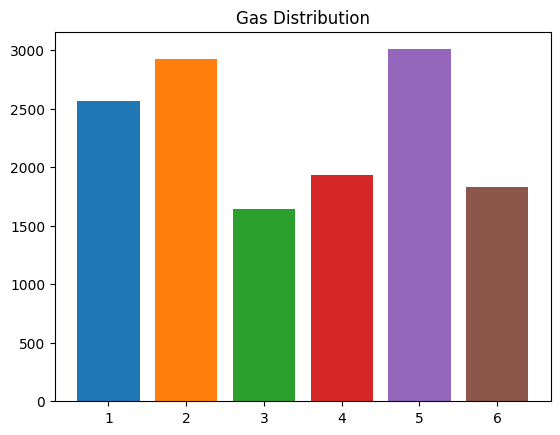

In [8]:
# Plot gas distribution
plt.bar(counts.index, counts.values, color=plt.cm.tab10(range(len(counts))))

plt.title("Gas Distribution")
plt.xticks()
plt.show()

In [9]:
pd.crosstab(df_all.batch_id, df_all.gas_type, normalize="index")

gas_type,1,2,3,4,5,6
batch_id,,,,,,
1,0.202247,0.220225,0.186517,0.067416,0.157303,0.166292
2,0.131833,0.268489,0.080386,0.087621,0.427653,0.004019
3,0.230139,0.308953,0.136192,0.151324,0.173392,0.000000
4,0.397516,0.267081,0.074534,0.186335,0.074534,0.000000
5,0.142132,0.203046,0.101523,0.233503,0.319797,0.000000
6,0.223478,0.249565,0.047826,0.012609,0.263478,0.203043
7,0.179629,0.183227,0.099640,0.205923,0.174370,0.157210
8,0.102041,0.102041,0.136054,0.112245,0.486395,0.061224
9,0.129787,0.117021,0.212766,0.159574,0.165957,0.214894


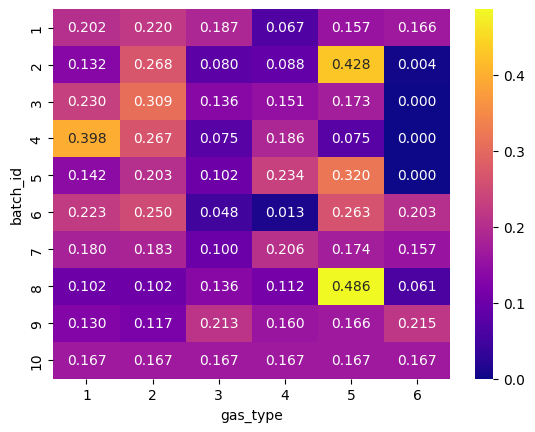

In [10]:
# Gas distribution in each batch
sns.heatmap(pd.crosstab(df_all.batch_id, df_all.gas_type, normalize="index"), cmap="plasma", annot=True, fmt=".3f");

In [11]:
# Plots the class distribution grouping batches 1-5 as the training set and keeping remaining batches (test sets) separate
def plot_initial_batch_distribution(df):
 
    df_copy = df.copy()
    df_copy['batch_group'] = df_copy['batch_id'].apply(
        lambda x: '1-5' if x <= 5 else str(x)
    )
    
    # Compute row-normalized crosstab
    ct = pd.crosstab(df_copy['batch_group'], df_copy['gas_type'], normalize="index")
    # print(ct)
    
    # Ensure correct ordering
    max_batch = df['batch_id'].max()
    expected_order = ['1-5'] + [str(i) for i in range(6, max_batch + 1)]
    ct = ct.reindex([idx for idx in expected_order if idx in ct.index])
    
    # Plotting
    plt.figure(figsize=(9, 4))
    sns.heatmap(ct, cmap="plasma", annot=True, fmt=".3f", linewidths=0.5)
    plt.title("Class Distribution: Training Set (1-5) vs. Individual Test Batches", fontsize=12)
    plt.xlabel("Gas Type")
    plt.ylabel("Batch Group / ID")
    plt.tight_layout()
    plt.show()

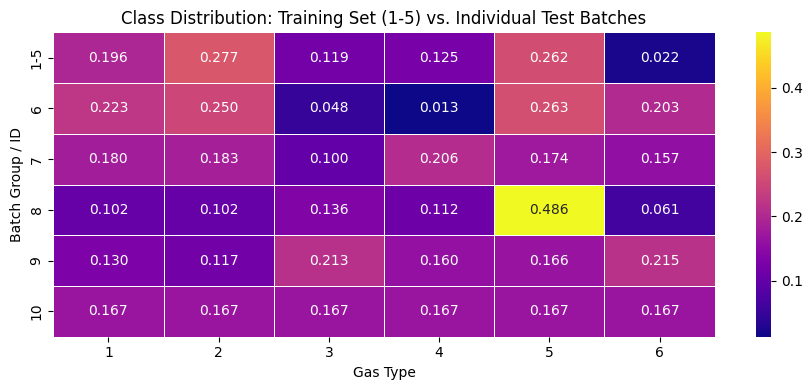

In [12]:
# Gas distribution in static training vs test batches
plot_initial_batch_distribution(df_all)

In [13]:
# Plots the class distribution where the training set grows cumulatively (1-6, 1-7, 1-8, 1-9) against the remaining test batches
def plot_cumulative_training_heatmaps(df):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    train_end_steps = [6, 7, 8, 9]
    max_batch = df['batch_id'].max()
    
    for i, end_batch in enumerate(train_end_steps):
        df_copy = df.copy()
        
        # Dynamically group the cumulative training set
        def map_batches(b):
            if b <= end_batch:
                return f"1-{end_batch}"
            else:
                return str(b)
                
        df_copy['batch_group'] = df_copy['batch_id'].apply(map_batches)
        
        # Compute crosstab
        ct = pd.crosstab(df_copy['batch_group'], df_copy['gas_type'], normalize="index")
        
        # Order rows: cumulative training group first, then sequential remaining batches
        expected_index = [f"1-{end_batch}"] + [str(b) for b in range(end_batch + 1, max_batch + 1)]
        ct = ct.reindex([idx for idx in expected_index if idx in ct.index])
        # print(ct)
        
        # Plot onto the specific subplot axis
        sns.heatmap(
            ct, 
            cmap="plasma", 
            annot=True, 
            fmt=".3f", 
            ax=axes[i], 
            cbar=False,
            linewidths=0.5
        )
        
        axes[i].set_title(f"Cumulative Train: Batches 1–{end_batch}", fontsize=11)
        axes[i].set_xlabel("Gas Type")
        axes[i].set_ylabel("Batch Group / ID")
        
    plt.suptitle("Evolution of Training vs. Test Class Distributions", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

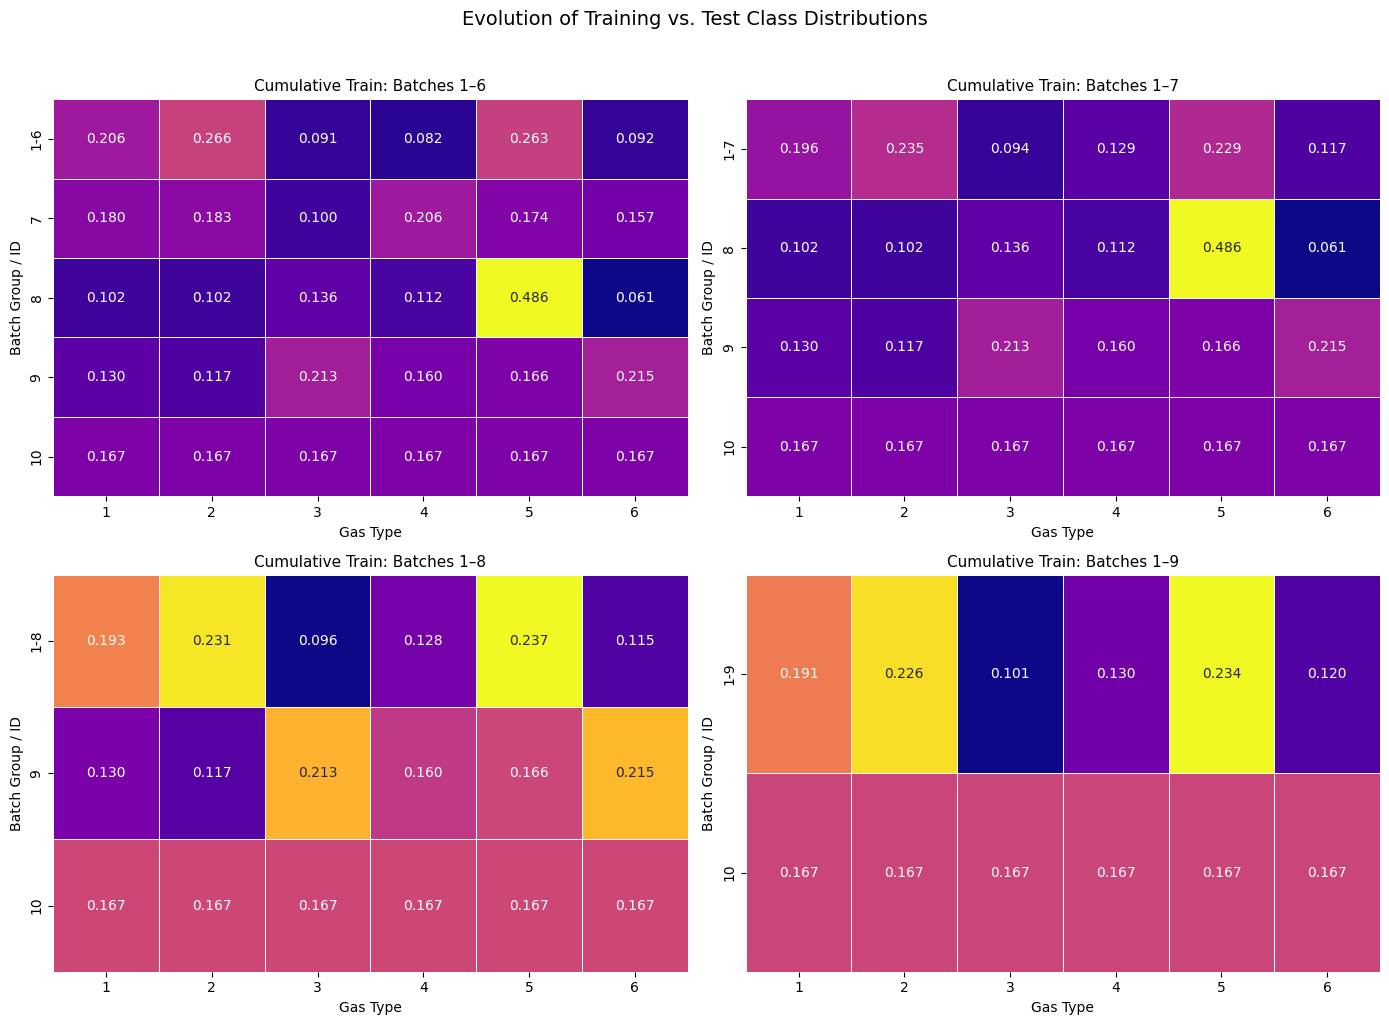

In [14]:
# Gas distribution in adaptive training vs test batches
plot_cumulative_training_heatmaps(df_all)

### Temporal Split: Train, Validation and Test Sets

In [15]:
df_train = df_all[df_all.batch_id <= 5]

In [16]:
print("Training Set:", df_train.shape)

Training Set: (3633, 130)


In [17]:
df_test = df_all[df_all.batch_id > 5]
print("Test Set:", df_test.shape)

Test Set: (10277, 130)


In [18]:
df_test1 = df_all[df_all.batch_id == 6]
print("Test Set 1:", df_test1.shape)
df_test2 = df_all[df_all.batch_id == 7]
print("Test Set 2:", df_test2.shape)
df_test3 = df_all[df_all.batch_id == 8]
print("Test Set 3:", df_test3.shape)
df_test4 = df_all[df_all.batch_id == 9]
print("Test Set 4:", df_test4.shape)
df_test5 = df_all[df_all.batch_id == 10]
print("Test Set 5:", df_test5.shape)

Test Set 1: (2300, 130)
Test Set 2: (3613, 130)
Test Set 3: (294, 130)
Test Set 4: (470, 130)
Test Set 5: (3600, 130)


In [19]:
X_train = df_train.drop(columns=["gas_type", "batch_id"])
y_train = df_train.gas_type

X_test = df_test.drop(columns=["gas_type", "batch_id"])
y_test = df_test.gas_type

X_test1 = df_test1.drop(columns=["gas_type", "batch_id"])
y_test1 = df_test1.gas_type
X_test2 = df_test2.drop(columns=["gas_type", "batch_id"])
y_test2 = df_test2.gas_type
X_test3 = df_test3.drop(columns=["gas_type", "batch_id"])
y_test3 = df_test3.gas_type
X_test4 = df_test4.drop(columns=["gas_type", "batch_id"])
y_test4 = df_test4.gas_type
X_test5 = df_test5.drop(columns=["gas_type", "batch_id"])
y_test5 = df_test5.gas_type

#### Standardization

In [20]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

X_test_s1 = scaler.transform(X_test1)
X_test_s2 = scaler.transform(X_test2)
X_test_s3 = scaler.transform(X_test3)
X_test_s4 = scaler.transform(X_test4)
X_test_s5 = scaler.transform(X_test5)

## Static Learning

### MODEL 1: Logistic Regression

In [21]:
model_1 = LogisticRegression(max_iter=5000)

model_1.fit(X_train_s, y_train)

LogisticRegression(max_iter=5000)

In [22]:
pred = model_1.predict(X_test_s)

pred1 = model_1.predict(X_test_s1)
pred2 = model_1.predict(X_test_s2)
pred3 = model_1.predict(X_test_s3)
pred4 = model_1.predict(X_test_s4)
pred5 = model_1.predict(X_test_s5)

In [23]:
results_static_m1 = []

for batch, y_true, y_pred in [
    ("6-10", y_test, pred),
    (6, y_test1, pred1),
    (7, y_test2, pred2),
    (8, y_test3, pred3),
    (9, y_test4, pred4),
    (10, y_test5, pred5)
]:

    results_static_m1.append({
        "batch": batch,
        "accuracy": accuracy_score(y_true, y_pred),
        "bal_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"
        )
    })

In [24]:
print("     model: Logistic Regressor")
print("-----------------------------------")

for r in results_static_m1:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

     model: Logistic Regressor
-----------------------------------
Batch:    6-10
Accuracy: 0.611
Balanced Accuracy: 0.597
Macro F1: 0.548
-----------------------------------
Batch:    6
Accuracy: 0.776
Balanced Accuracy: 0.808
Macro F1: 0.658
-----------------------------------
Batch:    7
Accuracy: 0.648
Balanced Accuracy: 0.661
Macro F1: 0.596
-----------------------------------
Batch:    8
Accuracy: 0.510
Balanced Accuracy: 0.535
Macro F1: 0.501
-----------------------------------
Batch:    9
Accuracy: 0.617
Balanced Accuracy: 0.659
Macro F1: 0.574
-----------------------------------
Batch:    10
Accuracy: 0.475
Balanced Accuracy: 0.475
Macro F1: 0.424
-----------------------------------


### MODEL 2: SVM

In [25]:
model_2 = SVC(
    kernel="rbf",
    probability=True,
    C=10,
    gamma="scale"
)

model_2.fit(X_train_s, y_train)

SVC(C=10, probability=True)

In [26]:
pred  = model_2.predict(X_test_s)

pred1 = model_2.predict(X_test_s1)
pred2 = model_2.predict(X_test_s2)
pred3 = model_2.predict(X_test_s3)
pred4 = model_2.predict(X_test_s4)
pred5 = model_2.predict(X_test_s5)

In [27]:
results_static_m2 = []

for batch, y_true, y_pred in [
    ("6-10", y_test, pred),
    (6, y_test1, pred1),
    (7, y_test2, pred2),
    (8, y_test3, pred3),
    (9, y_test4, pred4),
    (10, y_test5, pred5)
]:

    results_static_m2.append({
        "batch": batch,
        "accuracy": accuracy_score(y_true, y_pred),
        "bal_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"
        )
    })

In [28]:
print("        model: SVM (RBF)")
print("-----------------------------------")

for r in results_static_m2:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

        model: SVM (RBF)
-----------------------------------
Batch:    6-10
Accuracy: 0.643
Balanced Accuracy: 0.641
Macro F1: 0.609
-----------------------------------
Batch:    6
Accuracy: 0.740
Balanced Accuracy: 0.783
Macro F1: 0.633
-----------------------------------
Batch:    7
Accuracy: 0.741
Balanced Accuracy: 0.737
Macro F1: 0.693
-----------------------------------
Batch:    8
Accuracy: 0.806
Balanced Accuracy: 0.743
Macro F1: 0.686
-----------------------------------
Batch:    9
Accuracy: 0.760
Balanced Accuracy: 0.807
Macro F1: 0.737
-----------------------------------
Batch:    10
Accuracy: 0.456
Balanced Accuracy: 0.456
Macro F1: 0.444
-----------------------------------


### MODEL 3: Random Forest

In [29]:
model_3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model_3.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [30]:
pred  = model_3.predict(X_test)

pred1 = model_3.predict(X_test1)
pred2 = model_3.predict(X_test2)
pred3 = model_3.predict(X_test3)
pred4 = model_3.predict(X_test4)
pred5 = model_3.predict(X_test5)

In [31]:
results_static_m3 = []

for batch, y_true, y_pred in [
    ("6-10", y_test, pred),
    (6, y_test1, pred1),
    (7, y_test2, pred2),
    (8, y_test3, pred3),
    (9, y_test4, pred4),
    (10, y_test5, pred5)
]:

    results_static_m3.append({
        "batch": batch,
        "accuracy": accuracy_score(y_true, y_pred),
        "bal_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"
        )
    })

In [32]:
print("      MODEL: Random Forest")
print("-----------------------------------")

for r in results_static_m3:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

      MODEL: Random Forest
-----------------------------------
Batch:    6-10
Accuracy: 0.522
Balanced Accuracy: 0.511
Macro F1: 0.471
-----------------------------------
Batch:    6
Accuracy: 0.713
Balanced Accuracy: 0.766
Macro F1: 0.625
-----------------------------------
Batch:    7
Accuracy: 0.579
Balanced Accuracy: 0.592
Macro F1: 0.535
-----------------------------------
Batch:    8
Accuracy: 0.190
Balanced Accuracy: 0.220
Macro F1: 0.107
-----------------------------------
Batch:    9
Accuracy: 0.562
Balanced Accuracy: 0.574
Macro F1: 0.536
-----------------------------------
Batch:    10
Accuracy: 0.364
Balanced Accuracy: 0.364
Macro F1: 0.352
-----------------------------------


### MODEL 4: XGBoost

In [33]:
model_4 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

y_train_xgb = y_train - 1

model_4.fit(X_train, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
pred  = model_4.predict(X_test)

pred1 = model_4.predict(X_test1)
pred2 = model_4.predict(X_test2)
pred3 = model_4.predict(X_test3)
pred4 = model_4.predict(X_test4)
pred5 = model_4.predict(X_test5)

In [35]:
results_static_m4 = []

for batch, y_true, y_pred in [
    ("6-10", y_test, pred),
    (6, y_test1, pred1),
    (7, y_test2, pred2),
    (8, y_test3, pred3),
    (9, y_test4, pred4),
    (10, y_test5, pred5)
]:

    results_static_m4.append({
        "batch": batch,
        "accuracy": accuracy_score(y_true, y_pred+1),
        "bal_accuracy": balanced_accuracy_score(y_true, y_pred+1),
        "macro_f1": f1_score(y_true, y_pred+1, average="macro"
        )
    })

In [36]:
print("         model: XGBoost")
print("-----------------------------------")

for r in results_static_m4:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

         model: XGBoost
-----------------------------------
Batch:    6-10
Accuracy: 0.513
Balanced Accuracy: 0.507
Macro F1: 0.482
-----------------------------------
Batch:    6
Accuracy: 0.620
Balanced Accuracy: 0.696
Macro F1: 0.575
-----------------------------------
Batch:    7
Accuracy: 0.577
Balanced Accuracy: 0.588
Macro F1: 0.550
-----------------------------------
Batch:    8
Accuracy: 0.320
Balanced Accuracy: 0.356
Macro F1: 0.274
-----------------------------------
Batch:    9
Accuracy: 0.557
Balanced Accuracy: 0.553
Macro F1: 0.454
-----------------------------------
Batch:    10
Accuracy: 0.390
Balanced Accuracy: 0.390
Macro F1: 0.370
-----------------------------------


### MODEL 5: MLP

In [37]:
model_5 = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1000,
    random_state=42
)

model_5.fit(X_train_s, y_train)

MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)

In [38]:
pred  = model_5.predict(X_test_s)

pred1 = model_5.predict(X_test_s1)
pred2 = model_5.predict(X_test_s2)
pred3 = model_5.predict(X_test_s3)
pred4 = model_5.predict(X_test_s4)
pred5 = model_5.predict(X_test_s5)

In [39]:
results_static_m5 = []

for batch, y_true, y_pred in [
    ("6-10", y_test, pred),
    (6, y_test1, pred1),
    (7, y_test2, pred2),
    (8, y_test3, pred3),
    (9, y_test4, pred4),
    (10, y_test5, pred5)
]:

    results_static_m5.append({
        "batch": batch,
        "accuracy": accuracy_score(y_true, y_pred),
        "bal_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"
        )
    })

In [40]:
print("            MODEL: MLP")
print("-----------------------------------")

for r in results_static_m5:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

            MODEL: MLP
-----------------------------------
Batch:    6-10
Accuracy: 0.625
Balanced Accuracy: 0.614
Macro F1: 0.562
-----------------------------------
Batch:    6
Accuracy: 0.760
Balanced Accuracy: 0.798
Macro F1: 0.697
-----------------------------------
Batch:    7
Accuracy: 0.661
Balanced Accuracy: 0.674
Macro F1: 0.612
-----------------------------------
Batch:    8
Accuracy: 0.776
Balanced Accuracy: 0.612
Macro F1: 0.573
-----------------------------------
Batch:    9
Accuracy: 0.530
Balanced Accuracy: 0.525
Macro F1: 0.443
-----------------------------------
Batch:    10
Accuracy: 0.501
Balanced Accuracy: 0.501
Macro F1: 0.452
-----------------------------------


### Robustness Analysis

In [41]:
# Combine metrics into a single dataframe
dfs = [pd.DataFrame.from_dict(results_static_m1).iloc[1:6], 
       pd.DataFrame.from_dict(results_static_m2).iloc[1:6],
       pd.DataFrame.from_dict(results_static_m3).iloc[1:6],
       pd.DataFrame.from_dict(results_static_m4).iloc[1:6],
       pd.DataFrame.from_dict(results_static_m5).iloc[1:6]
      ]

for i, df in enumerate(dfs, start=1):
    df['#Model'] = i

results_static = pd.concat(dfs, ignore_index=True)

model_names = {
    1: "LogReg",
    2: "SVM",
    3: "RF",
    4: "XGB",
    5: "MLP"
}
results_static['Model'] = results_static['#Model'].map(model_names)

results_static

,batch,accuracy,bal_accuracy,macro_f1,#Model,Model
0,6,0.775652,0.808229,0.657590,1,LogReg
1,7,0.648492,0.660719,0.595730,1,LogReg
2,8,0.510204,0.535402,0.500649,1,LogReg
3,9,0.617021,0.658974,0.573926,1,LogReg
4,10,0.475000,0.475000,0.423510,1,LogReg
5,6,0.739565,0.783068,0.633347,2,SVM
6,7,0.740936,0.737457,0.692951,2,SVM
7,8,0.806122,0.743211,0.686257,2,SVM
8,9,0.759574,0.807350,0.736637,2,SVM
9,10,0.455833,0.455833,0.443735,2,SVM


#### Visualize Temporal Drift

In [42]:
# Plots Accuracy, Balanced Accuracy, and Macro F1 side-by-side over time (batches) for all models in the dataframe
def plot_metrics_over_time(df, save_path=None):

    metrics = [
        ("accuracy", "Accuracy"),
        ("bal_accuracy", "Balanced Accuracy"),
        ("macro_f1", "Macro F1")
    ]
    
    # Create a 1x3 subplot grid side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
    
    for i, (metric_key, metric_name) in enumerate(metrics):
        ax = axes[i]
        
        for model_name in df["Model"].unique():
            tmp = df[df["Model"] == model_name]
            
            ax.plot(
                tmp["batch"],
                tmp[metric_key],
                marker="o",
                label=model_name
            )
        
        ax.set_xticks(range(6, 11))
        ax.set_xlabel("Batch")
        ax.set_ylabel(metric_name)
        ax.set_title(metric_name)
        ax.grid(True)
    
    # Create a single shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc="upper center", 
        bbox_to_anchor=(0.5, 1.05), 
        ncol=len(labels), 
        frameon=True
    )
    
    # Adjust layout to make room for the top legend
    plt.tight_layout()
    
    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Plot successfully saved to: {save_path}")
        
    plt.show()

Plot successfully saved to: Images/temporal_drift_static.png


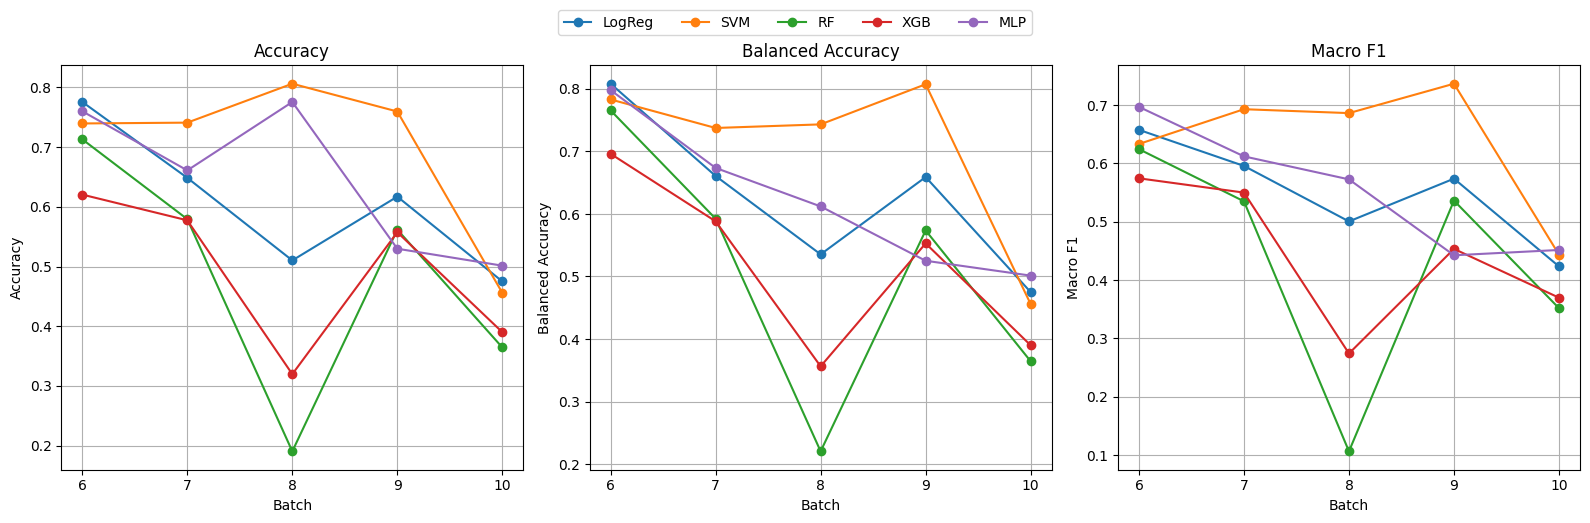

In [43]:
plot_metrics_over_time(results_static, "Images/temporal_drift_static.png")

#### Degradation

In [44]:
# Compute degradation as the difference betweent the metrics obtained in batch 6 and those obtained in batch 10
b6 = results_static[results_static['batch'] == 6].set_index('Model')
b10 = results_static[results_static['batch'] == 10].set_index('Model')

metrics = ['accuracy', 'bal_accuracy', 'macro_f1']

degradation_df = b10[metrics] - b6[metrics]
degradation_df.columns = [f'deg_{m}' for m in metrics]

degradation_df = degradation_df.reset_index()
degradation_df

,Model,deg_accuracy,deg_bal_accuracy,deg_macro_f1
0,LogReg,-0.300652,-0.333229,-0.234079
1,SVM,-0.283732,-0.327235,-0.189613
2,RF,-0.348599,-0.401139,-0.272579
3,XGB,-0.230435,-0.306136,-0.204595
4,MLP,-0.258611,-0.296541,-0.245232


#### Robustness

In [45]:
# Compute robustness as the average of each metric across the five test batches (6-10)
robustness_df = pd.DataFrame({
    "rob_accuracy": results_static.groupby("Model")["accuracy"].mean(),
    "rob_bal_accuracy": results_static.groupby("Model")["bal_accuracy"].mean(),
    "rob_macro_f1": results_static.groupby("Model")["macro_f1"].mean()
})

robustness_df = robustness_df.reset_index()
robustness_df

,Model,rob_accuracy,rob_bal_accuracy,rob_macro_f1
0,LogReg,0.605274,0.627665,0.550281
1,MLP,0.645527,0.622022,0.555224
2,RF,0.481793,0.503284,0.430890
3,SVM,0.700406,0.705384,0.638585
4,XGB,0.492994,0.516721,0.444467


#### Confusion Matrices

We focus on the best performing model in terms of robustness, which was SVM (model_2).

In [46]:
batches = [
    (6, X_test_s1, y_test1),
    (7, X_test_s1, y_test1),
    (8, X_test_s3, y_test3),
    (9, X_test_s4, y_test4),
    (10, X_test_s5, y_test5)
]

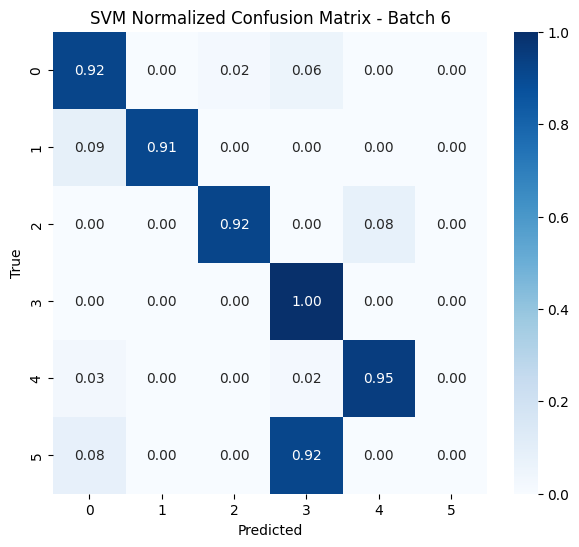

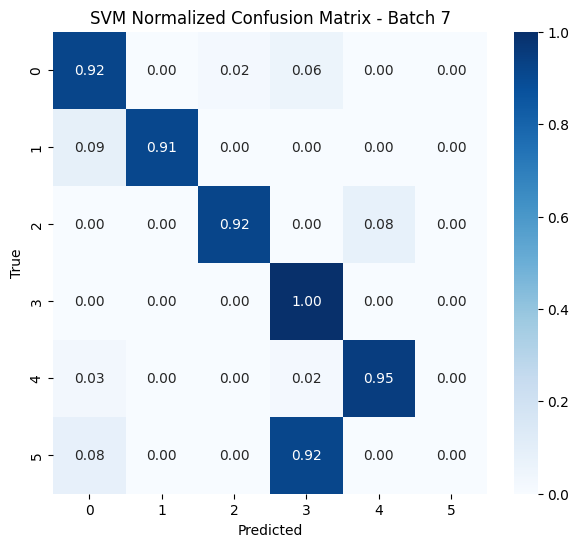

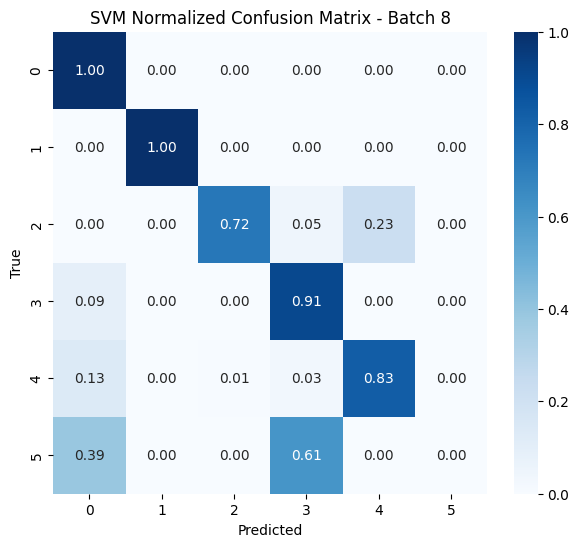

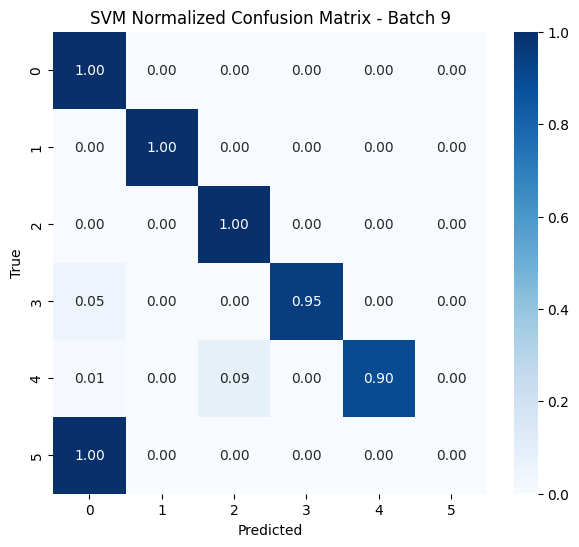

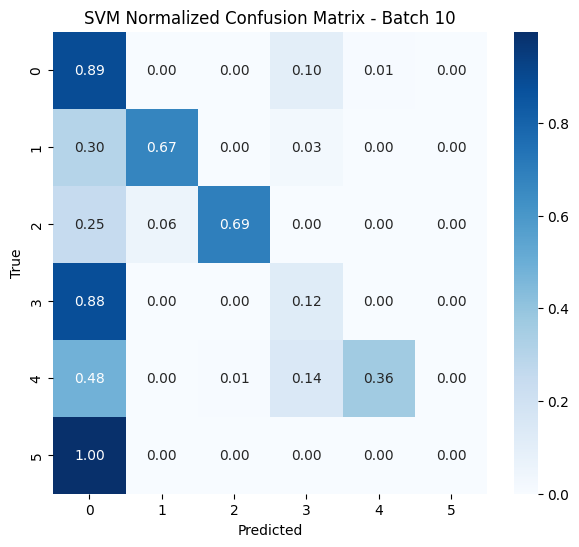

In [47]:
# Plot all confusion matrices for each test batch (6-10)
for batch_id, X_batch, y_batch in batches:

    pred = model_2.predict(X_batch)

    cm = confusion_matrix(
        y_batch,
        pred,
        normalize="true"
    )

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )

    plt.title(
        f"SVM Normalized Confusion Matrix - Batch {batch_id}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

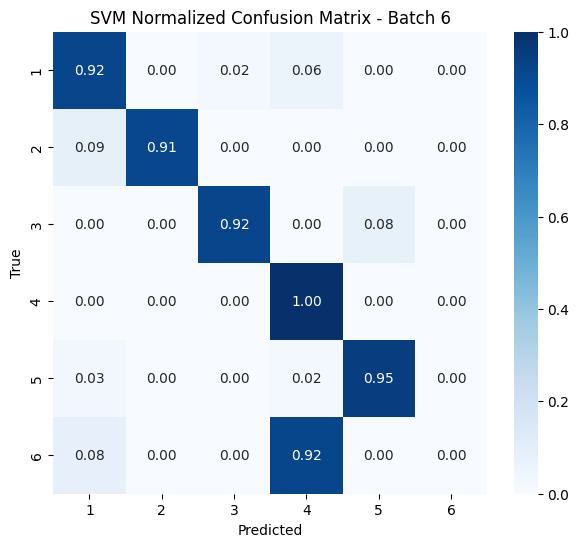

In [48]:
# Plot and save as a image the confusion matrices of batch 6 and batch 10, which are used in the report 
pred = model_2.predict(X_test_s1)

cm = confusion_matrix(
    y_test1,
    pred,
    normalize="true"
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[1,2,3,4,5,6],  
    yticklabels=[1,2,3,4,5,6]   
)

plt.title(
    f"SVM Normalized Confusion Matrix - Batch 6"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig("Images/cm_6_static.png", bbox_inches="tight")
plt.show()

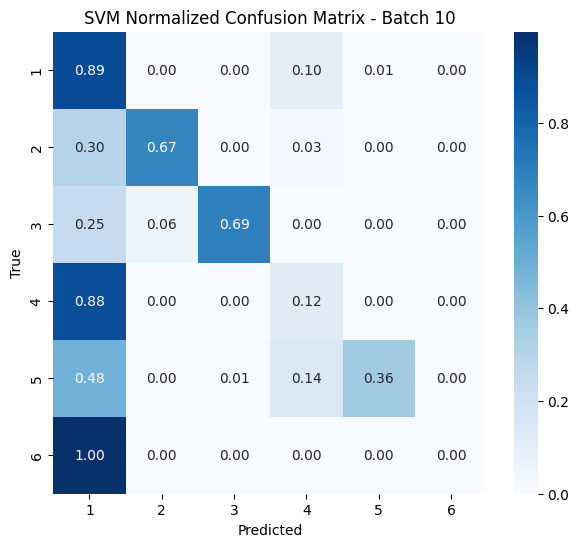

In [49]:
pred = model_2.predict(X_test_s5)

cm = confusion_matrix(
    y_test5,
    pred,
    normalize="true"
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[1,2,3,4,5,6],  
    yticklabels=[1,2,3,4,5,6]   
)

plt.title(
    f"SVM Normalized Confusion Matrix - Batch 10"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig("Images/cm_10_static.png", bbox_inches="tight")
plt.show()

#### PCA

In [50]:
pca = PCA(n_components=2)

pca.fit(X_train_s)

PCA(n_components=2)

In [51]:
batchs = {}

for b in range(1, 11):

    tmp = df_all[df_all.batch_id == b]

    X_tmp = tmp.drop(
        columns=["gas_type", "batch_id"]
    )

    X_tmp = scaler.transform(X_tmp)

    batchs[b] = pca.transform(X_tmp)

##### All Batches

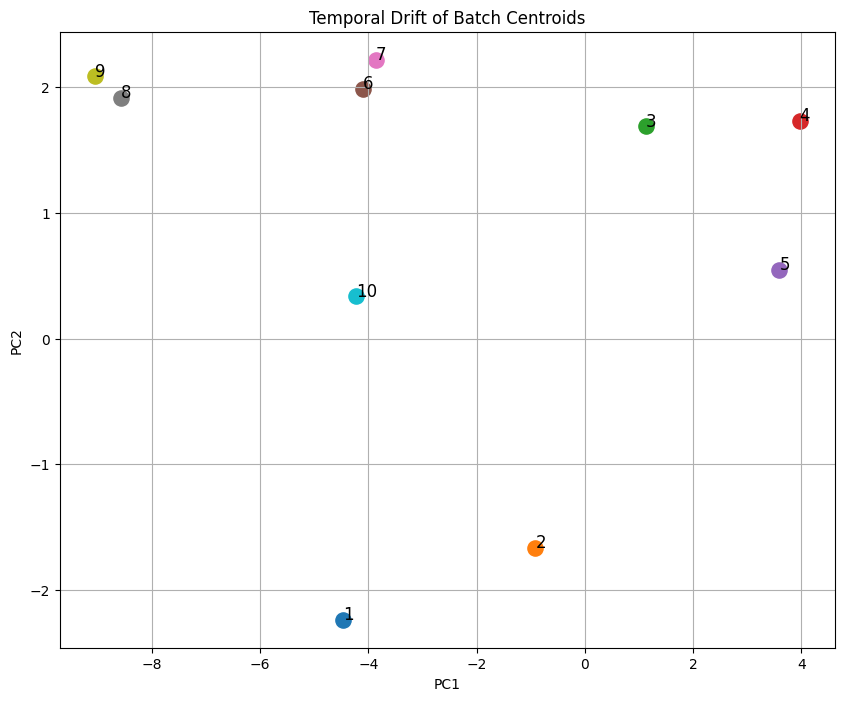

In [52]:
plt.figure(figsize=(10,8))

for b in range(1,11):

    coords = batchs[b]

    center = coords.mean(axis=0)

    plt.scatter(
        center[0],
        center[1],
        s=120
    )

    plt.text(
        center[0],
        center[1],
        str(b),
        fontsize=12
    )

plt.title(
    "Temporal Drift of Batch Centroids"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(True)
plt.show()

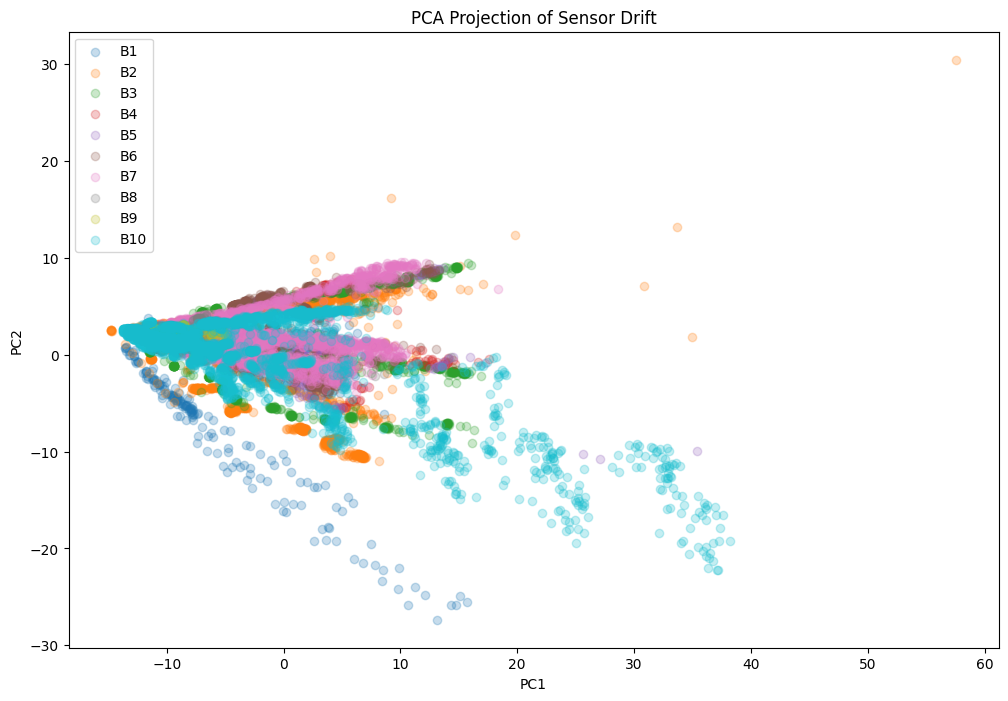

In [53]:
plt.figure(figsize=(12,8))

for b in [1,2,3,4,5,6,7,8,9,10]:

    coords = batchs[b]

    plt.scatter(
        coords[:,0],
        coords[:,1],
        alpha=0.25,
        label=f"B{b}"
    )

plt.legend()

plt.title(
    "PCA Projection of Sensor Drift"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

##### Combined Training + Individual Batches

In [54]:
# Helper function to process any batch or range of batches
def get_batch_coords(batch_ids):
    if isinstance(batch_ids, int):
        batch_ids = [batch_ids]
    tmp = df_all[df_all.batch_id.isin(batch_ids)]
    X_tmp = tmp.drop(columns=["gas_type", "batch_id"])
    return pca.transform(scaler.transform(X_tmp))

In [55]:
# Extract training data and individual batches cleanly
train_coords = get_batch_coords(range(1, 6))
batchs = {b: get_batch_coords(b) for b in range(6, 11)}

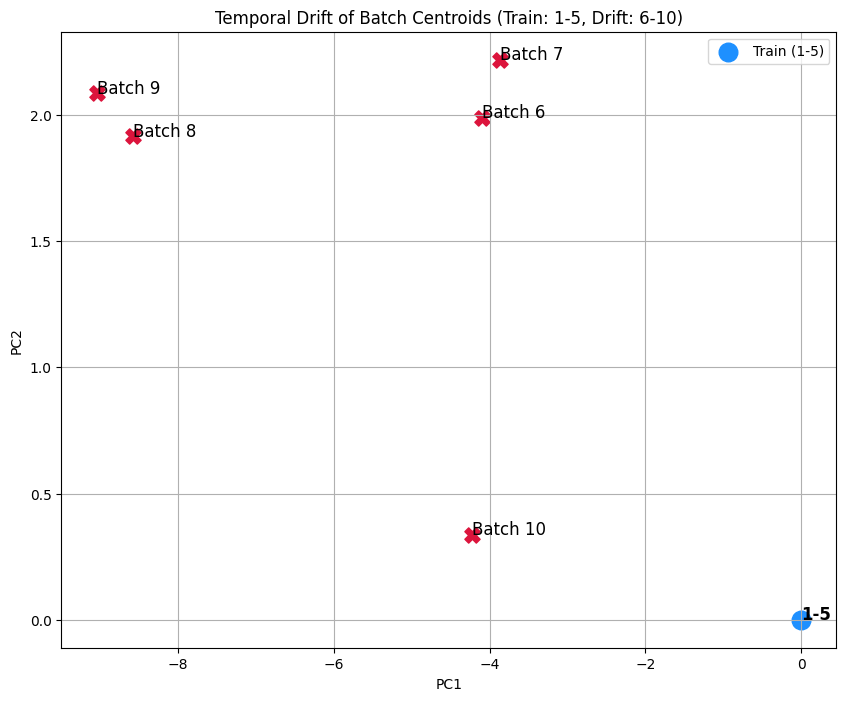

In [56]:
# Plot centroids of the combined training set and individual test batches
plt.figure(figsize=(10, 8))
center_train = train_coords.mean(axis=0)

plt.scatter(center_train[0], center_train[1], s=180, color='dodgerblue', marker='o', label='Train (1-5)')
plt.text(center_train[0], center_train[1], '1-5', fontsize=12, fontweight='bold')

for b, coords in batchs.items():
    center = coords.mean(axis=0)
    plt.scatter(center[0], center[1], s=120, color='crimson', marker='X')
    plt.text(center[0], center[1], f"Batch {b}", fontsize=12)

plt.title("Temporal Drift of Batch Centroids (Train: 1-5, Drift: 6-10)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend()
plt.savefig("Images/pca_centroids_static.png", bbox_inches="tight")
plt.show()

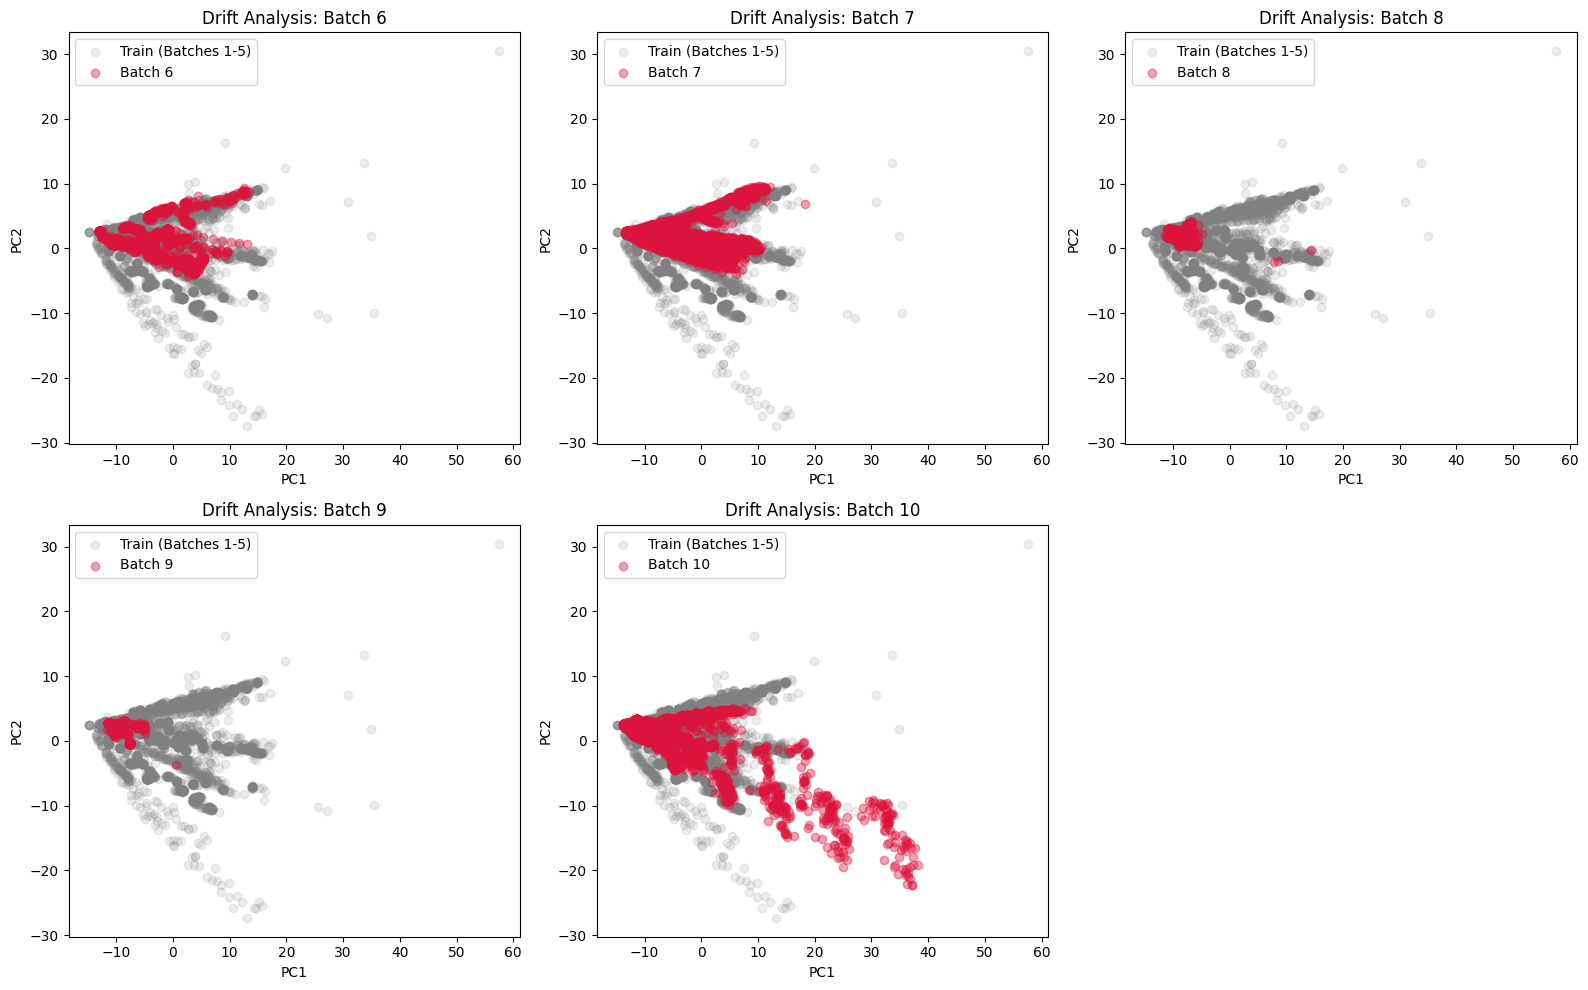

In [57]:
# Plot individual drift subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, b in enumerate(range(6, 11)):
    ax = axes[i]
    
    # Plot training baseline
    ax.scatter(train_coords[:, 0], train_coords[:, 1], alpha=0.15, color="gray", label="Train (Batches 1-5)")
    
    # Plot individual target batch
    ax.scatter(batchs[b][:, 0], batchs[b][:, 1], alpha=0.4, color="crimson", label=f"Batch {b}")
    
    ax.set_title(f"Drift Analysis: Batch {b}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig("Images/pca_batch_drift_analysis_static.png", bbox_inches="tight")
plt.show()

In [58]:
# Compute and print the distance between centroids of every test batch and that of the training set
train_scaled = scaler.transform(X_train)
train_pca = pca.transform(train_scaled)
train_center = train_pca.mean(axis=0)

distances = []

for b in range(6,11):

    tmp = df_all[df_all.batch_id == b]

    X_tmp = scaler.transform(
        tmp.drop(
            columns=["gas_type", "batch_id"]
        )
    )

    coords = pca.transform(X_tmp)

    center = coords.mean(axis=0)

    distance = np.linalg.norm(
        center - train_center
    )

    distances.append(
        [b, distance]
    )

dist_df = pd.DataFrame(
    distances,
    columns=["batch", "distance"]
)

print(dist_df)

   batch  distance
0      6  4.559596
1      7  4.456366
2      8  8.788617
3      9  9.286221
4     10  4.245418


#### By class

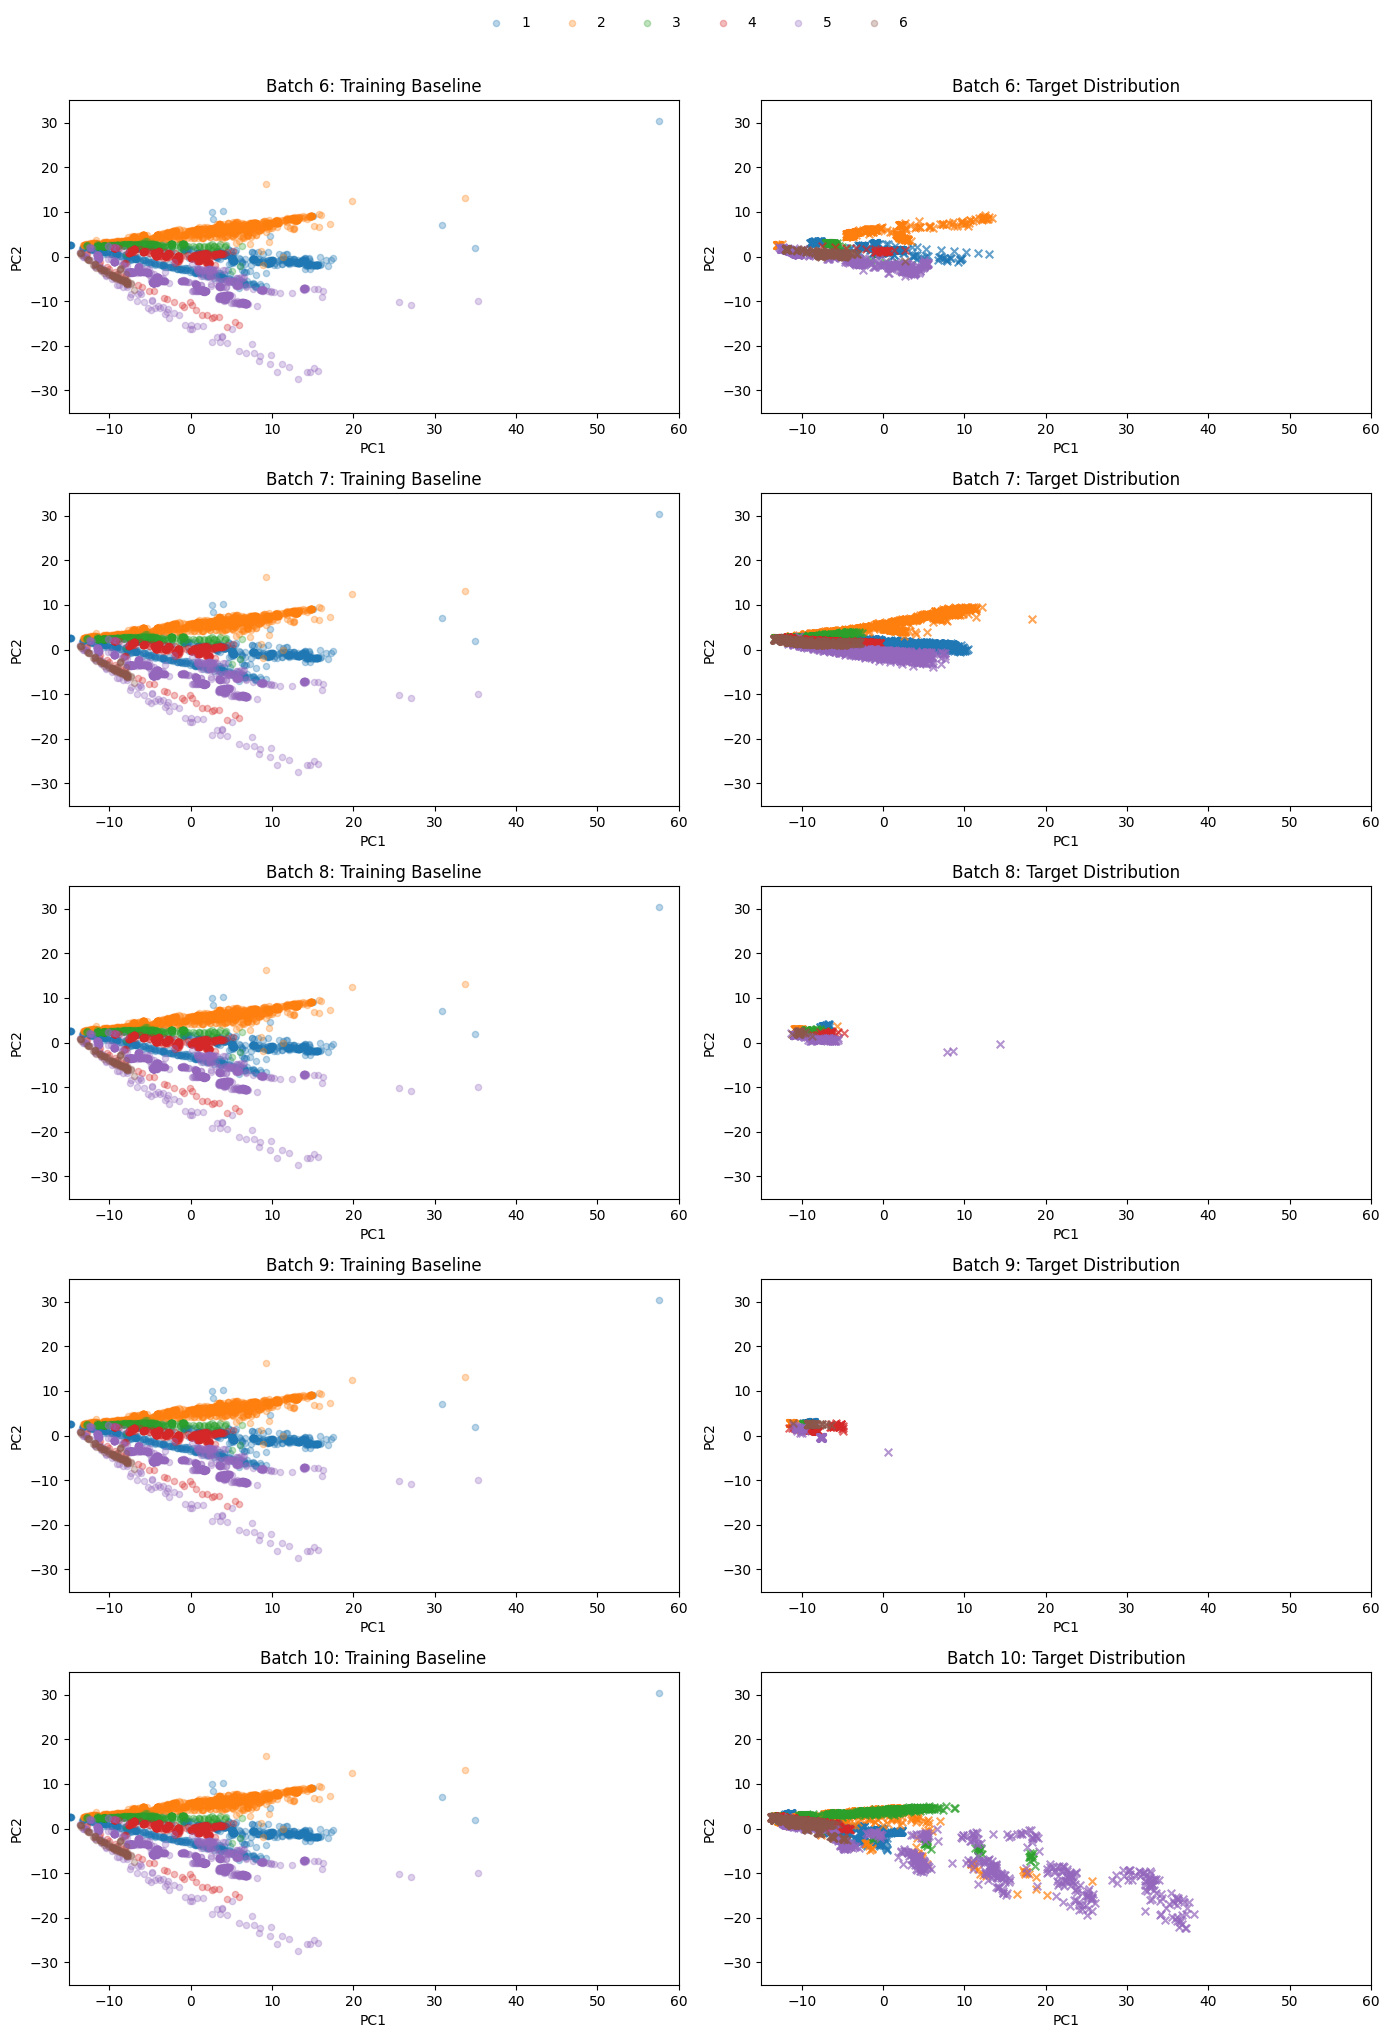

In [59]:
# Extract training data along with their gas types
train_df = df_all[df_all.batch_id.isin(range(1, 6))]
X_train = train_df.drop(columns=["gas_type", "batch_id"])
train_coords = pca.transform(scaler.transform(X_train))
train_gas_types = train_df["gas_type"].values

# Get unique gas types for consistent coloring
gas_types = sorted(df_all["gas_type"].unique())
palette = sns.color_palette("tab10", len(gas_types))
gas_color_map = dict(zip(gas_types, palette))

# Plots 5 rows (one for each test batch), with 2 side-by-side plots each
batches = range(6, 11)
fig, axes = plt.subplots(len(batches), 2, figsize=(14, 4 * len(batches)))

handles, labels = [], []
legend_added = set()

for i, b in enumerate(batches):
    ax_train = axes[i, 0]
    ax_target = axes[i, 1]

    # Set consistent axis limits for all plots
    for ax in [ax_train, ax_target]:
        ax.set_xlim(-15, 60)
        ax.set_ylim(-35, 35)

    # Left subplot: training set (in static learning is the same across batches)
    for gas in gas_types:
        mask = train_gas_types == gas
        scatter = ax_train.scatter(
            train_coords[mask, 0],
            train_coords[mask, 1],
            alpha=0.3,
            color=gas_color_map[gas],
            s=20,
        )
        
        # Collect unique legend handles for gas types only once
        if gas not in legend_added:
            handles.append(scatter)
            labels.append(str(gas))
            legend_added.add(gas)

    ax_train.set_title(f"Batch {b}: Training Baseline")
    ax_train.set_xlabel("PC1")
    ax_train.set_ylabel("PC2")

    # Right subplot: test batch
    target_df = df_all[df_all.batch_id == b]
    X_target = target_df.drop(columns=["gas_type", "batch_id"])
    target_coords = pca.transform(scaler.transform(X_target))
    target_gas_types = target_df["gas_type"].values

    for gas in gas_types:
        mask = target_gas_types == gas
        ax_target.scatter(
            target_coords[mask, 0],
            target_coords[mask, 1],
            alpha=0.7,
            color=gas_color_map[gas],
            marker="x",
            s=30,
        )

    ax_target.set_title(f"Batch {b}: Target Distribution")
    ax_target.set_xlabel("PC1")
    ax_target.set_ylabel("PC2")

# Place a single shared legend above the figure
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(gas_types),
    fontsize="medium",
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.99])  # Leave space at the top for the legend
plt.savefig("Images/pca_class_drift_analysis_static.png", bbox_inches="tight")
plt.show()

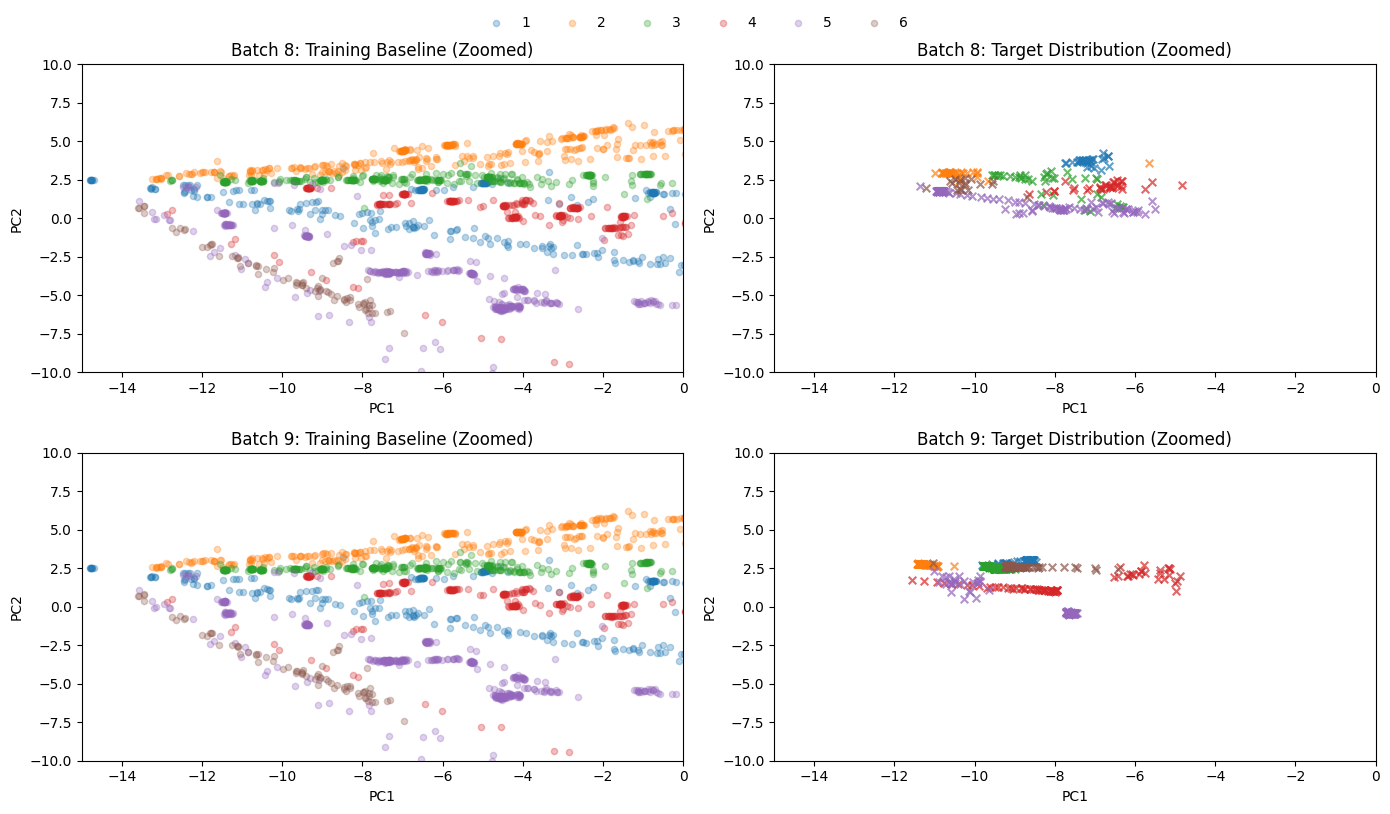

In [60]:
# Focus on batch 8 and 9, to better visualize the drift in the small region in which samples are clumped
train_df = df_all[df_all.batch_id.isin(range(1, 6))]
X_train = train_df.drop(columns=["gas_type", "batch_id"])
train_coords = pca.transform(scaler.transform(X_train))
train_gas_types = train_df["gas_type"].values

gas_types = sorted(df_all["gas_type"].unique())
palette = sns.color_palette("tab10", len(gas_types))
gas_color_map = dict(zip(gas_types, palette))

batches = [8, 9]
fig, axes = plt.subplots(len(batches), 2, figsize=(14, 4 * len(batches)))

handles, labels = [], []
legend_added = set()

for i, b in enumerate(batches):
    ax_train = axes[i, 0]
    ax_target = axes[i, 1]

    # Set zoomed-in axis limits for all plots
    for ax in [ax_train, ax_target]:
        ax.set_xlim(-15, 0)
        ax.set_ylim(-10, 10)

    # Left subplot: training set
    for gas in gas_types:
        mask = train_gas_types == gas
        scatter = ax_train.scatter(
            train_coords[mask, 0],
            train_coords[mask, 1],
            alpha=0.3,
            color=gas_color_map[gas],
            s=20,
        )
        
        # Collect unique legend handles for gas types only once
        if gas not in legend_added:
            handles.append(scatter)
            labels.append(str(gas))
            legend_added.add(gas)

    ax_train.set_title(f"Batch {b}: Training Baseline (Zoomed)")
    ax_train.set_xlabel("PC1")
    ax_train.set_ylabel("PC2")

    # Right subplot: test batch
    target_df = df_all[df_all.batch_id == b]
    X_target = target_df.drop(columns=["gas_type", "batch_id"])
    target_coords = pca.transform(scaler.transform(X_target))
    target_gas_types = target_df["gas_type"].values

    for gas in gas_types:
        mask = target_gas_types == gas
        ax_target.scatter(
            target_coords[mask, 0],
            target_coords[mask, 1],
            alpha=0.7,
            color=gas_color_map[gas],
            marker="x",
            s=30,
        )

    ax_target.set_title(f"Batch {b}: Target Distribution (Zoomed)")
    ax_target.set_xlabel("PC1")
    ax_target.set_ylabel("PC2")

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(gas_types),
    fontsize="medium",
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig("Images/pca_class_drift_analysis_zoomed_8_9.png", bbox_inches="tight")
plt.show()

#### Class-wise F1 evolution

In [61]:
f1_records = []

for b, y_test, pred in [
    (6, y_test1, pred1),
    (7, y_test2, pred2),
    (8, y_test3, pred3),
    (9, y_test4, pred4),
    (10, y_test5, pred5)
]:
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    
    class_f1s = {
        str(cls): metrics['f1-score'] 
        for cls, metrics in report.items() 
        if cls not in ['accuracy', 'macro avg', 'weighted avg', 'micro avg']
    }
    
    class_f1s['Batch'] = b
    f1_records.append(class_f1s)

df_f1_evolution = pd.DataFrame(f1_records).set_index('Batch')
df_f1_evolution

,1,2,3,4,5,6
Batch,,,,,,
6,0.897596,0.953510,0.874459,0.698795,0.736181,0.021097
7,0.672199,0.956795,0.827068,0.430141,0.752000,0.034602
8,0.750000,0.928571,0.613636,0.185185,0.958904,0.000000
9,0.374233,0.103448,0.925926,0.292135,0.960000,0.000000
10,0.417712,0.833656,0.770850,0.000000,0.688030,0.000000


### ENSEMBLES

I implemented also two different ensembles (hard and soft voting), but decided to keep it out of the analysis to focus on the difference between static and adaptive learning. 

In [62]:
from scipy.stats import mode

In [63]:
def hard_vote_predict(X_scaled, X_raw):
    preds = np.array([
        model_1.predict(X_scaled),
        model_2.predict(X_scaled),
        model_3.predict(X_raw),
        model_4.predict(X_raw)+1,
        model_5.predict(X_scaled)
    ]) 
    
    majority_preds, _ = mode(preds, axis=0, keepdims=False)
    return majority_preds

def soft_vote_predict(X_scaled, X_raw):

    p_lr  = model_1.predict_proba(X_scaled)
    p_svm = model_2.predict_proba(X_scaled)
    p_rf = model_3.predict_proba(X_raw)
    p_xgb = model_4.predict_proba(X_raw)
    p_mlp = model_5.predict_proba(X_scaled)

    p_avg = (
        p_lr +
        p_svm +
        p_rf +
        p_xgb +
        p_mlp
    ) / 5

    return np.argmax(p_avg, axis=1) + 1

In [64]:
ensemble_results_static = []

tests = [
    (6, X_test_s1, X_test1, y_test1),
    (7, X_test_s2, X_test2, y_test2),
    (8, X_test_s3, X_test3, y_test3),
    (9, X_test_s4, X_test4, y_test4),
    (10, X_test_s5, X_test5, y_test5)
]

for batch, Xs, Xr, y in tests:

    # Majority (Hard) Voting
    pred_hard = hard_vote_predict(Xs, Xr)
    ensemble_results_static.append({
        "batch": batch,
        "accuracy": accuracy_score(y, pred_hard),
        "bal_accuracy": balanced_accuracy_score(y, pred_hard),
        "macro_f1": f1_score(y, pred_hard, average="macro"),
        "#model": "1-5",
        "model": "Majority Voting"
    })

    # Soft Voting
    pred = soft_vote_predict(Xs, Xr)
    
    ensemble_results_static.append({
        "batch": batch,
        "accuracy": accuracy_score(y,pred),
        "bal_accuracy": balanced_accuracy_score(y,pred),
        "macro_f1": f1_score(
            y,
            pred,
            average="macro"
        ),
        "#model": "1-5",
        "model": "Soft Voting"
    })

results_static = pd.concat([results_static, pd.DataFrame(ensemble_results_static)], ignore_index=True)

#### Visualize Temporal Drift

#### Degradation

In [65]:
b6 = results_static[results_static['batch'] == 6].set_index('Model')
b10 = results_static[results_static['batch'] == 10].set_index('Model')

metrics = ['accuracy', 'bal_accuracy', 'macro_f1']

degradation_df = b10[metrics] - b6[metrics]
degradation_df.columns = [f'deg_{m}' for m in metrics]

degradation_df = degradation_df.reset_index()
degradation_df

,Model,deg_accuracy,deg_bal_accuracy,deg_macro_f1
0,LogReg,-0.300652,-0.333229,-0.234079
1,SVM,-0.283732,-0.327235,-0.189613
2,RF,-0.348599,-0.401139,-0.272579
3,XGB,-0.230435,-0.306136,-0.204595
4,MLP,-0.258611,-0.296541,-0.245232
5,NaN,-0.271944,-0.309367,-0.201432
6,NaN,-0.258973,-0.296776,-0.192197


#### Robustness

In [66]:
robustness_df = pd.DataFrame({
    "rob_accuracy": results_static.groupby("Model")["accuracy"].mean(),
    "rob_bal_accuracy": results_static.groupby("Model")["bal_accuracy"].mean(),
    "rob_macro_f1": results_static.groupby("Model")["macro_f1"].mean()
})

robustness_df = robustness_df.reset_index()
robustness_df

,Model,rob_accuracy,rob_bal_accuracy,rob_macro_f1
0,LogReg,0.605274,0.627665,0.550281
1,MLP,0.645527,0.622022,0.555224
2,RF,0.481793,0.503284,0.430890
3,SVM,0.700406,0.705384,0.638585
4,XGB,0.492994,0.516721,0.444467


## Adaptive Learning

### Helpers

In [67]:
# Automatically performs cumulative training and tests on the next batch 
def adaptive_learning(model, df_train):

    res = []
    
    for batch in [6,7,8,9,10]:

        train_df = df_train
    
        test_df = df_all[
            df_all.batch_id == batch
        ]
    
        X_train = train_df.drop(
            columns=["gas_type","batch_id"]
        )
    
        y_train = train_df["gas_type"]
    
        X_test = test_df.drop(
            columns=["gas_type","batch_id"]
        )
    
        y_test = test_df["gas_type"]
    
        scaler = StandardScaler()
    
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # XGBClassifier requires labels starting from 0
        if isinstance(model, XGBClassifier):
            y_train_xgb = y_train - 1
            model.fit(X_train_s, y_train_xgb)
            pred = model.predict(X_test_s)+1
        else:
            model.fit(X_train_s, y_train)
            pred = model.predict(X_test_s)
    
        res.append({
    
            "batch": batch,
    
            "accuracy":
                accuracy_score(y_test,pred),
    
            "bal_accuracy":
                balanced_accuracy_score(
                    y_test,
                    pred
                ),
    
            "macro_f1":
                f1_score(
                    y_test,
                    pred,
                    average="macro"
                )
        })
    
        df_train = pd.concat(
            [df_train, test_df],
            ignore_index=True
        )
    return res

### MODEL 1: Logistic Regression

In [68]:
model_1 = LogisticRegression(
    max_iter=5000,
    random_state=42
)

adaptive_train = df_all[df_all.batch_id <= 5].copy()

results_adaptive_m1 = adaptive_learning(model_1, adaptive_train)

In [69]:
print("     MODEL: Logistic Regressor")
print("-----------------------------------")

for r in results_adaptive_m1:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

     MODEL: Logistic Regressor
-----------------------------------
Batch:    6
Accuracy: 0.776
Balanced Accuracy: 0.808
Macro F1: 0.658
-----------------------------------
Batch:    7
Accuracy: 0.833
Balanced Accuracy: 0.850
Macro F1: 0.826
-----------------------------------
Batch:    8
Accuracy: 0.918
Balanced Accuracy: 0.894
Macro F1: 0.890
-----------------------------------
Batch:    9
Accuracy: 0.770
Balanced Accuracy: 0.817
Macro F1: 0.756
-----------------------------------
Batch:    10
Accuracy: 0.715
Balanced Accuracy: 0.715
Macro F1: 0.707
-----------------------------------


### MODEL 2: SVM

In [70]:
model_2 = SVC(
    kernel="rbf",
    probability=True,
    C=10,
    gamma="scale"
)

adaptive_train = df_all[df_all.batch_id <= 5].copy()

results_adaptive_m2 = adaptive_learning(model_2, adaptive_train)

In [71]:
print("        MODEL: SVM (RBF)")
print("-----------------------------------")

for r in results_adaptive_m2:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

        MODEL: SVM (RBF)
-----------------------------------
Batch:    6
Accuracy: 0.740
Balanced Accuracy: 0.783
Macro F1: 0.633
-----------------------------------
Batch:    7
Accuracy: 0.877
Balanced Accuracy: 0.887
Macro F1: 0.878
-----------------------------------
Batch:    8
Accuracy: 0.915
Balanced Accuracy: 0.878
Macro F1: 0.900
-----------------------------------
Batch:    9
Accuracy: 0.772
Balanced Accuracy: 0.820
Macro F1: 0.751
-----------------------------------
Batch:    10
Accuracy: 0.730
Balanced Accuracy: 0.730
Macro F1: 0.728
-----------------------------------


### MODEL 3: Random Forest

In [72]:
model_3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

adaptive_train = df_all[df_all.batch_id <= 5].copy()

results_adaptive_m3 = adaptive_learning(model_3, adaptive_train)

In [73]:
print("      MODEL: Random Forest")
print("-----------------------------------")

for r in results_adaptive_m3:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

      MODEL: Random Forest
-----------------------------------
Batch:    6
Accuracy: 0.713
Balanced Accuracy: 0.766
Macro F1: 0.625
-----------------------------------
Batch:    7
Accuracy: 0.754
Balanced Accuracy: 0.763
Macro F1: 0.721
-----------------------------------
Batch:    8
Accuracy: 0.871
Balanced Accuracy: 0.747
Macro F1: 0.742
-----------------------------------
Batch:    9
Accuracy: 0.843
Balanced Accuracy: 0.876
Macro F1: 0.852
-----------------------------------
Batch:    10
Accuracy: 0.610
Balanced Accuracy: 0.610
Macro F1: 0.609
-----------------------------------


### MODEL 4: XGBoost

In [74]:
model_4 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

adaptive_train = df_all[df_all.batch_id <= 5].copy()

results_adaptive_m4 = adaptive_learning(model_4, adaptive_train)

In [75]:
print("         model: XGBoost")
print("-----------------------------------")

for r in results_adaptive_m4:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

         model: XGBoost
-----------------------------------
Batch:    6
Accuracy: 0.620
Balanced Accuracy: 0.696
Macro F1: 0.575
-----------------------------------
Batch:    7
Accuracy: 0.728
Balanced Accuracy: 0.736
Macro F1: 0.688
-----------------------------------
Batch:    8
Accuracy: 0.830
Balanced Accuracy: 0.742
Macro F1: 0.712
-----------------------------------
Batch:    9
Accuracy: 0.751
Balanced Accuracy: 0.786
Macro F1: 0.743
-----------------------------------
Batch:    10
Accuracy: 0.607
Balanced Accuracy: 0.607
Macro F1: 0.610
-----------------------------------


### MODEL 5: MLP

In [76]:
model_5 = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1000,
    random_state=42
)

adaptive_train = df_all[df_all.batch_id <= 5].copy()

results_adaptive_m5 = adaptive_learning(model_5, adaptive_train)

In [77]:
print("            MODEL: MLP")
print("-----------------------------------")

for r in results_adaptive_m5:

    print(f"Batch:    {r['batch']}")
    print(f"Accuracy: {r['accuracy']:.3f}")
    print(f"Balanced Accuracy: {r["bal_accuracy"]:.3f}")
    print(f"Macro F1: {r['macro_f1']:.3f}")
    print("-----------------------------------")

            MODEL: MLP
-----------------------------------
Batch:    6
Accuracy: 0.760
Balanced Accuracy: 0.798
Macro F1: 0.697
-----------------------------------
Batch:    7
Accuracy: 0.791
Balanced Accuracy: 0.810
Macro F1: 0.775
-----------------------------------
Batch:    8
Accuracy: 0.908
Balanced Accuracy: 0.874
Macro F1: 0.892
-----------------------------------
Batch:    9
Accuracy: 0.768
Balanced Accuracy: 0.816
Macro F1: 0.745
-----------------------------------
Batch:    10
Accuracy: 0.720
Balanced Accuracy: 0.720
Macro F1: 0.727
-----------------------------------


### Robustness Analysis

In [78]:
dfs = [pd.DataFrame.from_dict(results_adaptive_m1).iloc[0:5], 
       pd.DataFrame.from_dict(results_adaptive_m2).iloc[0:5],
       pd.DataFrame.from_dict(results_adaptive_m3).iloc[0:5],
       pd.DataFrame.from_dict(results_adaptive_m4).iloc[0:5],
       pd.DataFrame.from_dict(results_adaptive_m5).iloc[0:5]
      ]

for i, df in enumerate(dfs, start=1):
    df['#Model'] = i

results_adaptive = pd.concat(dfs, ignore_index=True)

model_names = {
    1: "LogReg",
    2: "SVM",
    3: "RF",
    4: "XGB",
    5: "MLP"
}
results_adaptive['Model'] = results_adaptive['#Model'].map(model_names)

results_adaptive

,batch,accuracy,bal_accuracy,macro_f1,#Model,Model
0,6,0.775652,0.808229,0.657590,1,LogReg
1,7,0.833379,0.849626,0.826398,1,LogReg
2,8,0.918367,0.894189,0.889971,1,LogReg
3,9,0.770213,0.817123,0.756134,1,LogReg
4,10,0.715278,0.715278,0.706997,1,LogReg
5,6,0.739565,0.783068,0.633347,2,SVM
6,7,0.877110,0.887044,0.877973,2,SVM
7,8,0.914966,0.877846,0.899889,2,SVM
8,9,0.772340,0.819832,0.750907,2,SVM
9,10,0.730000,0.730000,0.728278,2,SVM


#### Visualize Temporal Drift

Plot successfully saved to: Images/temporat_drift_adaptive.png


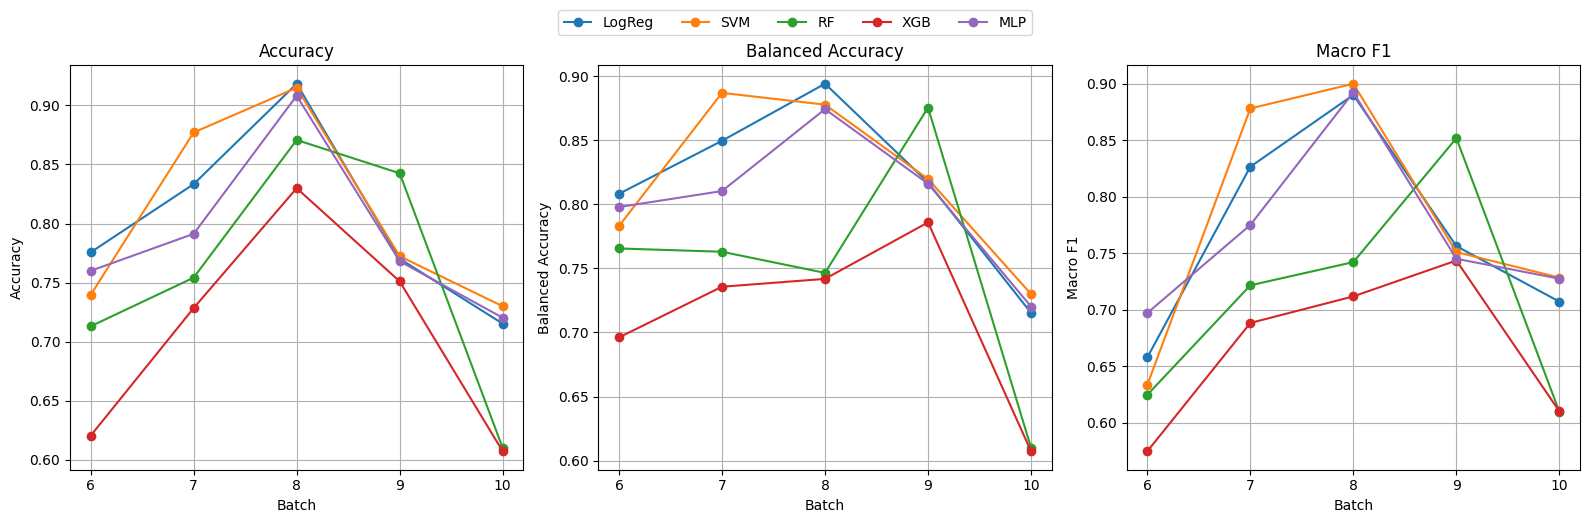

In [79]:
plot_metrics_over_time(results_adaptive, "Images/temporat_drift_adaptive.png")

#### Degradation

In [80]:
b6 = results_adaptive[results_adaptive['batch'] == 6].set_index('Model')
b10 = results_adaptive[results_adaptive['batch'] == 10].set_index('Model')

metrics = ['accuracy', 'bal_accuracy', 'macro_f1']

degradation_df = b10[metrics] - b6[metrics]
degradation_df.columns = [f'deg_{m}' for m in metrics]

degradation_df = degradation_df.reset_index()
degradation_df

,Model,deg_accuracy,deg_bal_accuracy,deg_macro_f1
0,LogReg,-0.060374,-0.092951,0.049407
1,SVM,-0.009565,-0.053068,0.094931
2,RF,-0.103043,-0.155583,-0.015035
3,XGB,-0.013213,-0.088914,0.035363
4,MLP,-0.039722,-0.077652,0.030388


#### Robustness

In [81]:
robustness_df = pd.DataFrame({
    "rob_accuracy": results_adaptive.groupby("Model")["accuracy"].mean(),
    "rob_bal_accuracy": results_adaptive.groupby("Model")["bal_accuracy"].mean(),
    "rob_macro_f1": results_adaptive.groupby("Model")["macro_f1"].mean()
})

robustness_df = robustness_df.reset_index()
robustness_df

,Model,rob_accuracy,rob_bal_accuracy,rob_macro_f1
0,LogReg,0.802578,0.816889,0.767418
1,MLP,0.789567,0.803816,0.767267
2,RF,0.758113,0.752146,0.709828
3,SVM,0.806796,0.819558,0.778079
4,XGB,0.707427,0.713375,0.665518


#### Confusion Matrix

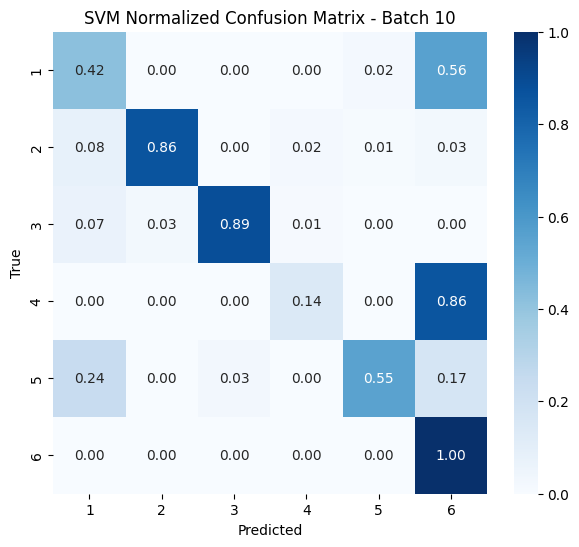

In [82]:
pred = model_2.predict(X_test_s5)

cm = confusion_matrix(
    y_test5+1,
    pred+1,
    normalize="true"
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[1,2,3,4,5,6],  
    yticklabels=[1,2,3,4,5,6]   
)

plt.title(
    f"SVM Normalized Confusion Matrix - Batch {batch_id}"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig("Images/cm_10_adaptive.png", bbox_inches="tight")
plt.show()

In [83]:
cm

array([[0.41833333, 0.        , 0.        , 0.00333333, 0.02333333,
        0.555     ],
       [0.08      , 0.86      , 0.00166667, 0.02166667, 0.01      ,
        0.02666667],
       [0.07      , 0.02666667, 0.885     , 0.015     , 0.        ,
        0.00333333],
       [0.        , 0.        , 0.        , 0.14166667, 0.        ,
        0.85833333],
       [0.24166667, 0.        , 0.03      , 0.00166667, 0.55333333,
        0.17333333],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        ]])

#### PCA

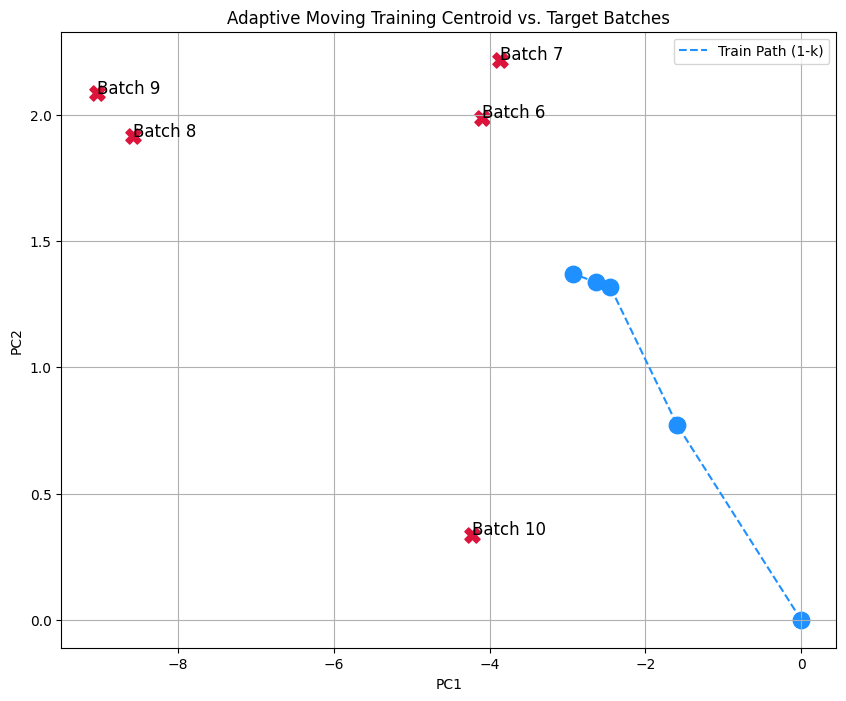

In [84]:
# Plot moving training centroids and individual target centroids
plt.figure(figsize=(10, 8))

# Track and plot cumulative training centroids (1-5 up to 1-9)
train_centroid_history = []
for k in range(5, 10):
    cum_train_coords = get_batch_coords(range(1, k + 1))
    center = cum_train_coords.mean(axis=0)
    train_centroid_history.append(center)
    
    # Plot each step of the expanding training set
    plt.scatter(center[0], center[1], s=140, color='dodgerblue', marker='o')
    # plt.text(center[0], center[1], f"1-{k}", fontsize=12, fontweight='bold')

# Connect the moving training centroids with a line to show the trajectory
train_centroid_history = np.array(train_centroid_history)
plt.plot(train_centroid_history[:, 0], train_centroid_history[:, 1], color='dodgerblue', linestyle='--', label="Train Path (1-k)")

# Plot individual target batches (6-10)
for b in range(6, 11):
    coords = get_batch_coords(b)
    center = coords.mean(axis=0)
    plt.scatter(center[0], center[1], s=120, color='crimson', marker='X')
    plt.text(center[0], center[1], f"Batch {b}", fontsize=12)

plt.title("Adaptive Moving Training Centroid vs. Target Batches")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend()
plt.savefig("Images/pca_centroids_adaptive.png", bbox_inches="tight")
plt.show()

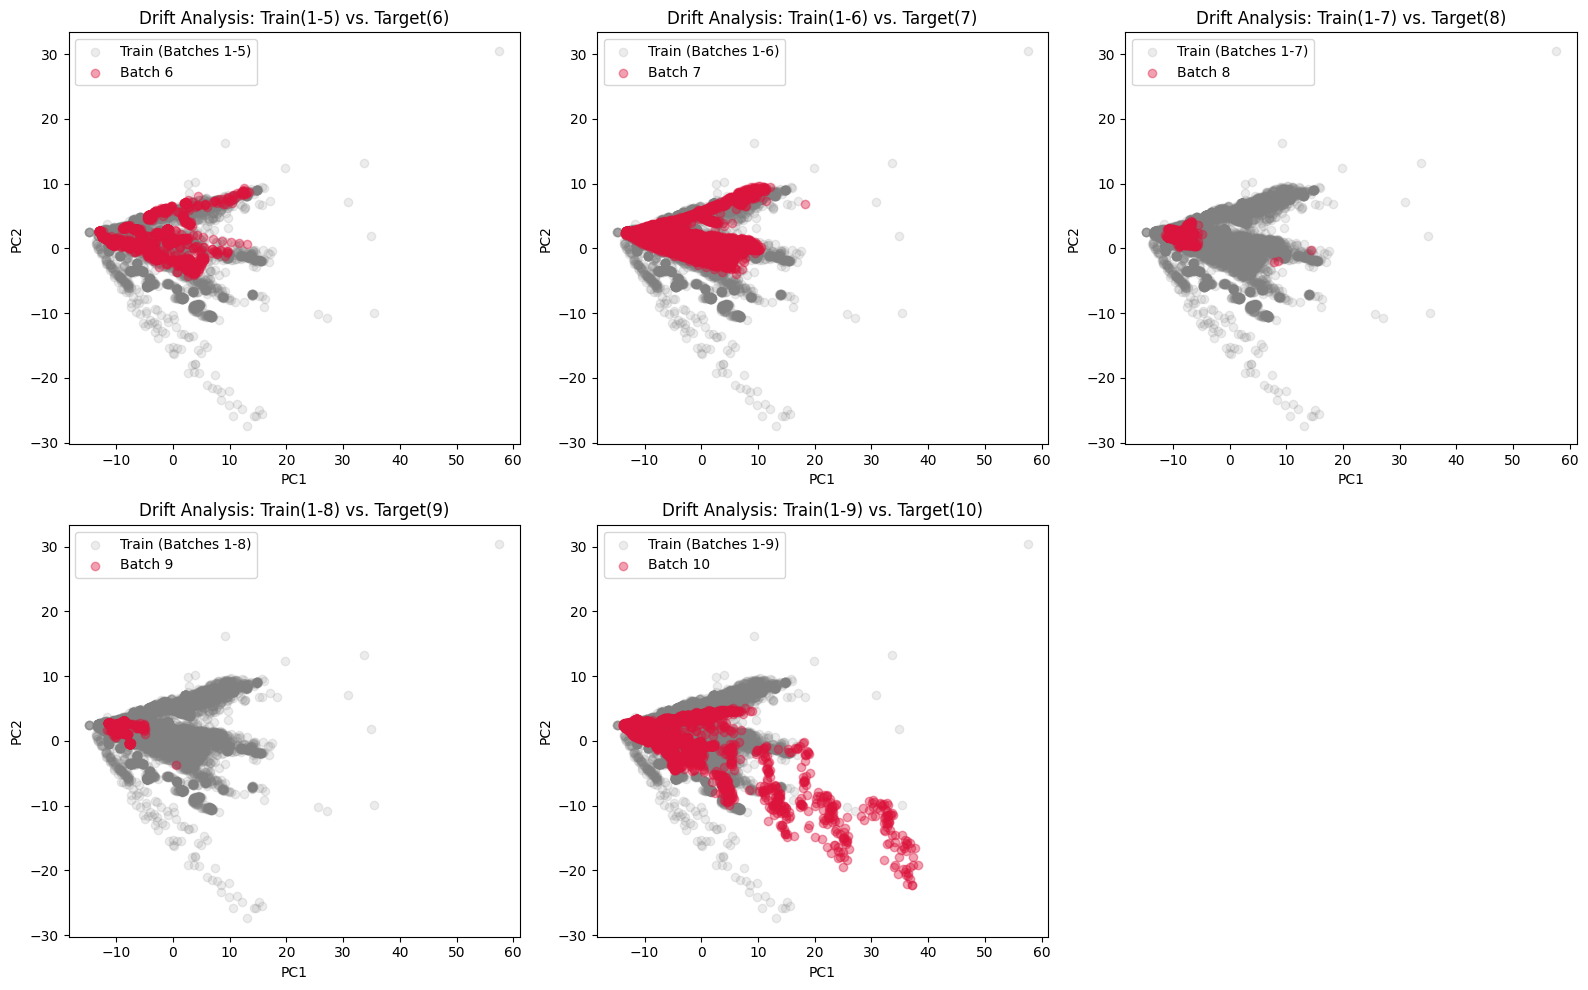

In [85]:
# Plot dynamic drift analysis subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, b in enumerate(range(6, 11)):
    ax = axes[i]
    
    # Dynamic training set: everything from batch 1 up to b-1
    dynamic_train_coords = get_batch_coords(range(1, b))
    
    # Plot dynamic training baseline
    ax.scatter(dynamic_train_coords[:, 0], dynamic_train_coords[:, 1], alpha=0.15, color="gray", label=f"Train (Batches 1-{b-1})")
    
    # Plot target batch
    ax.scatter(batchs[b][:, 0], batchs[b][:, 1], alpha=0.4, color="crimson", label=f"Batch {b}")
    
    ax.set_title(f"Drift Analysis: Train(1-{b-1}) vs. Target({b})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig("Images/pca_batch_drift_analysis_adaptive.png", bbox_inches="tight")
plt.show()

In [86]:
distances = []

for b in range(6, 11):
    # Get cumulative training data up to batch (b - 1)
    train_tmp = df_all[df_all.batch_id.isin(range(1, b))]
    X_train_cumul = train_tmp.drop(columns=["gas_type", "batch_id"])
    
    # Scale and transform cumulative train set
    train_scaled = scaler.transform(X_train_cumul)
    train_pca = pca.transform(train_scaled)
    train_center = train_pca.mean(axis=0)
    
    # Get current target batch (b) data
    target_tmp = df_all[df_all.batch_id == b]
    X_target = target_tmp.drop(columns=["gas_type", "batch_id"])
    
    # Scale and transform target batch
    target_scaled = scaler.transform(X_target)
    target_pca = pca.transform(target_scaled)
    target_center = target_pca.mean(axis=0)
    
    # Compute Euclidean distance between current target centroid and cumulative training centroid
    distance = np.linalg.norm(target_center - train_center)
    
    distances.append({
        "target_batch": b,
        "train_baseline": f"1-{b-1}",
        "distance": distance
    })

dist_df = pd.DataFrame(distances)
print(dist_df)

   target_batch train_baseline  distance
0             6            1-5  4.559596
1             7            1-6  2.695893
2             8            1-7  6.155113
3             9            1-8  6.458182
4            10            1-9  1.665400


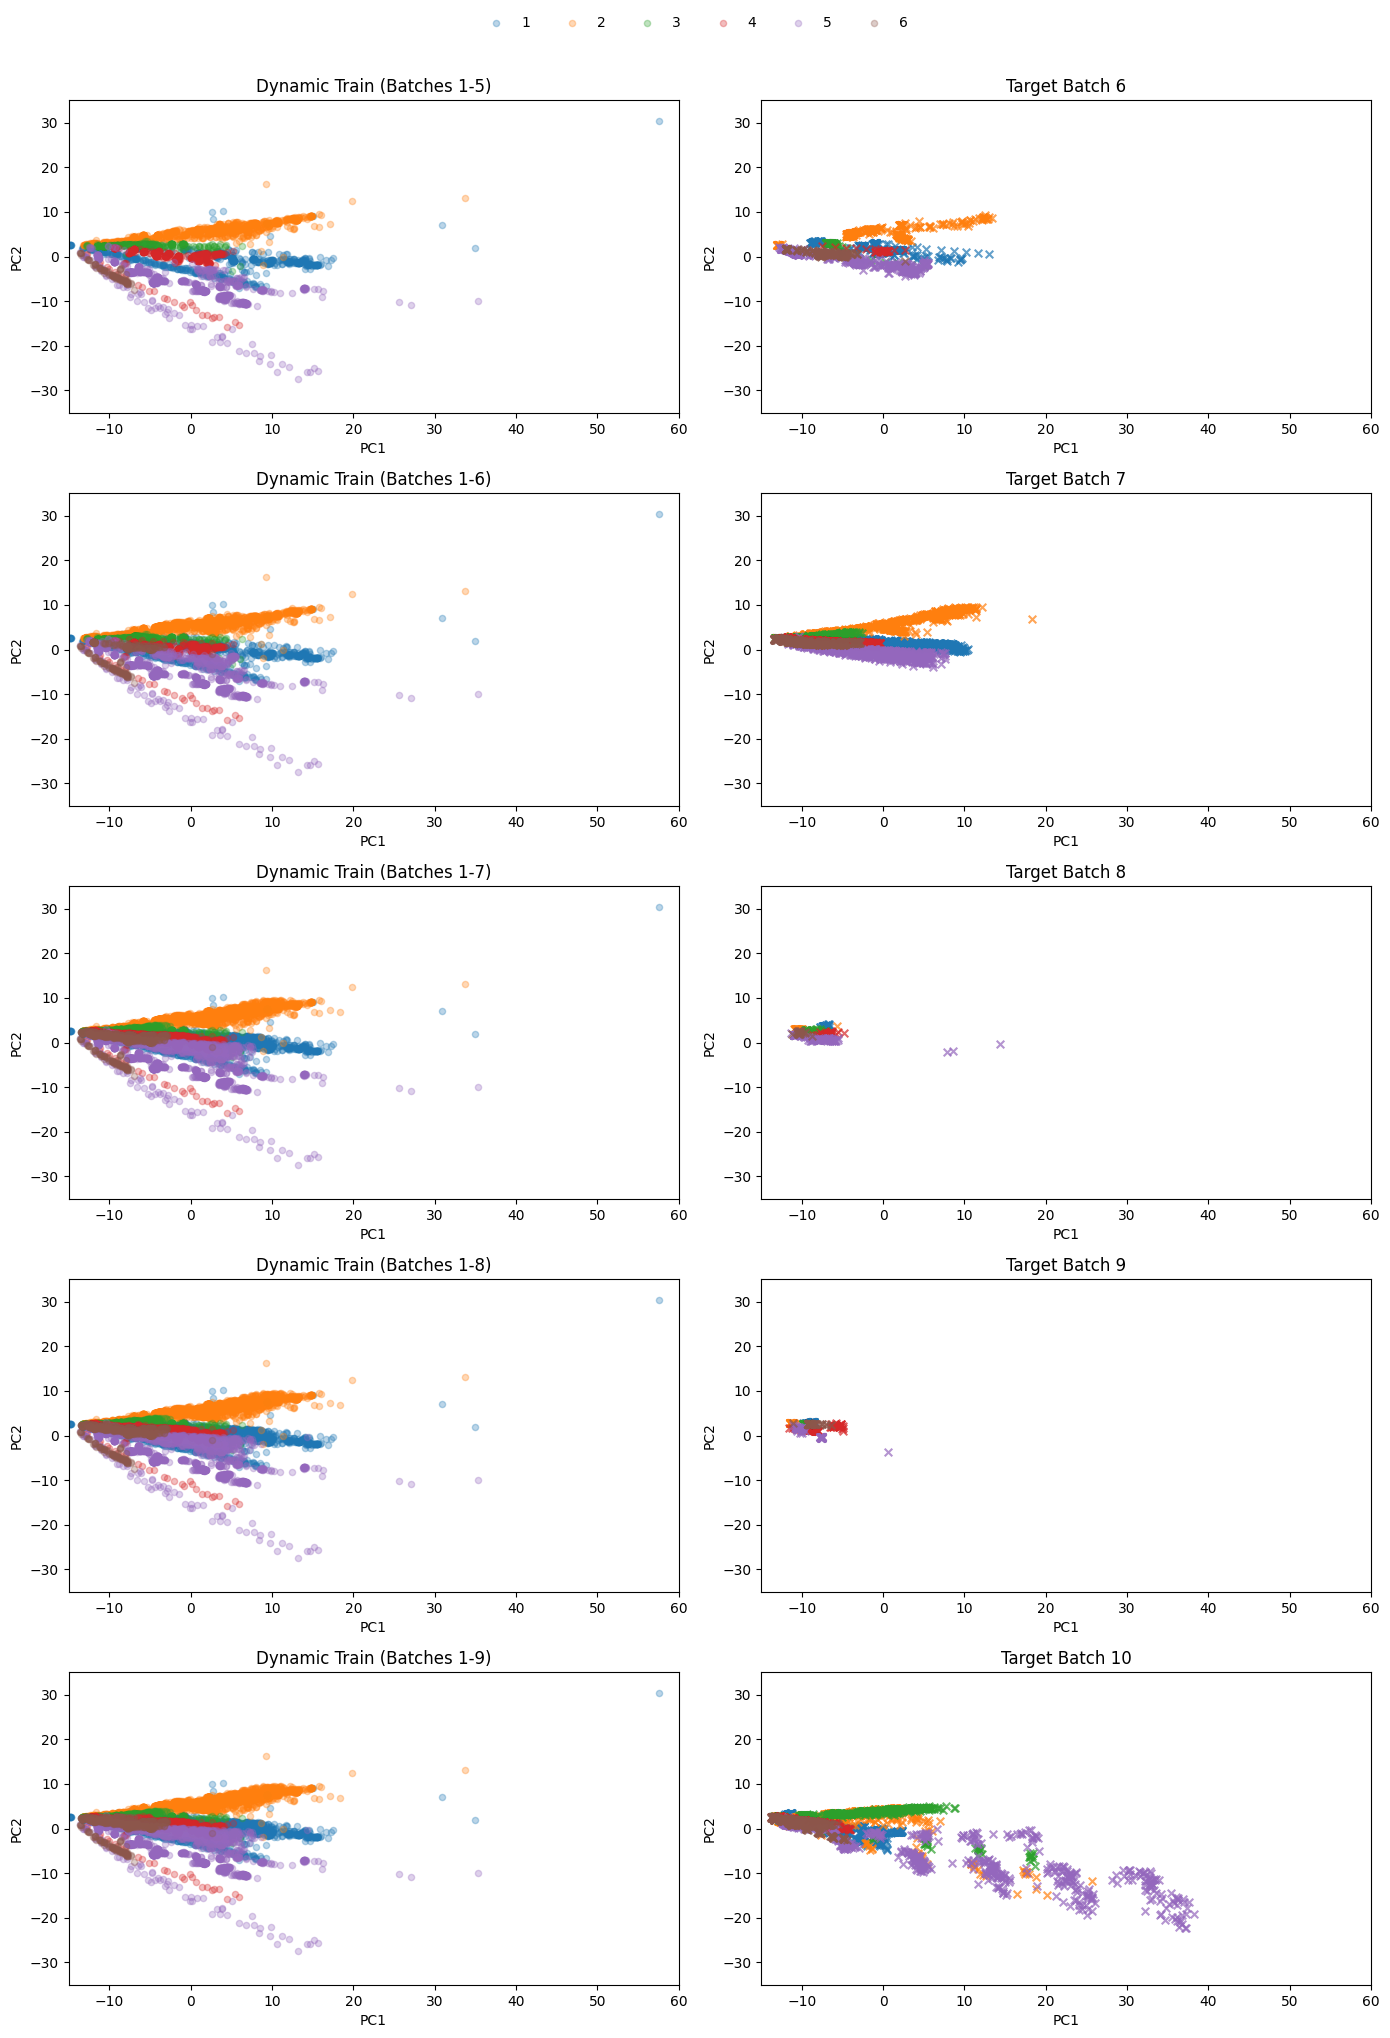

In [87]:
# Get unique gas types for consistent coloring
gas_types = sorted(df_all["gas_type"].unique())
palette = sns.color_palette("tab10", len(gas_types))
gas_color_map = dict(zip(gas_types, palette))

# Plot 5 rows (one for each target batch), with 2 side-by-side plots each
batches = range(6, 11)
fig, axes = plt.subplots(len(batches), 2, figsize=(14, 4 * len(batches)))

handles, labels = [], []
legend_added = set()

for i, b in enumerate(batches):
    ax_train = axes[i, 0]
    ax_target = axes[i, 1]

    # Set consistent axis limits for all plots
    for ax in [ax_train, ax_target]:
        ax.set_xlim(-15, 60)
        ax.set_ylim(-35, 35)

    # Left subplot: dynamic training set (Batches 1 to b-1)
    train_df = df_all[df_all.batch_id.isin(range(1, b))]
    X_train = train_df.drop(columns=["gas_type", "batch_id"])
    train_coords = pca.transform(scaler.transform(X_train))
    train_gas_types = train_df["gas_type"].values

    for gas in gas_types:
        mask = train_gas_types == gas
        if np.any(mask):
            scatter = ax_train.scatter(
                train_coords[mask, 0],
                train_coords[mask, 1],
                alpha=0.3,
                color=gas_color_map[gas],
                s=20,
            )
            
            # Collect unique legend handles for gas types only once
            if gas not in legend_added:
                handles.append(scatter)
                labels.append(str(gas))
                legend_added.add(gas)

    ax_train.set_title(f"Dynamic Train (Batches 1-{b-1})")
    ax_train.set_xlabel("PC1")
    ax_train.set_ylabel("PC2")

    # Right subplot: test set
    target_df = df_all[df_all.batch_id == b]
    X_target = target_df.drop(columns=["gas_type", "batch_id"])
    target_coords = pca.transform(scaler.transform(X_target))
    target_gas_types = target_df["gas_type"].values

    for gas in gas_types:
        mask = target_gas_types == gas
        if np.any(mask):
            ax_target.scatter(
                target_coords[mask, 0],
                target_coords[mask, 1],
                alpha=0.7,
                color=gas_color_map[gas],
                marker="x",
                s=30,
            )

    ax_target.set_title(f"Target Batch {b}")
    ax_target.set_xlabel("PC1")
    ax_target.set_ylabel("PC2")

# Place a single shared legend above the figure
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(gas_types),
    fontsize="medium",
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.99])  # Leave space at the top for the legend
plt.savefig("Images/pca_class_drift_analysis_adaptive.png", bbox_inches="tight")
plt.show()